# Compact production-shaped FX signal pipeline

Полноценный альтернативный pipeline для прямого сравнения с `prod_pipline.ipynb`. Он использует те же данные, исходные targets `G0/W1` и определения lift/BPS, но заменяет массовый поиск на компактную библиотеку интерпретируемых rule-семейств, pooled ML и один заменяемый selector.

Все границы выводятся из доступной истории: `36m rolling train → causal OOS warm-up → selector validation → один финальный holdout`. Конкретные даты печатаются перед результатами и не зашиты в алгоритм.

In [1]:
from datetime import date
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((
    p.resolve() for p in candidate_roots
    if (p / 'src' / 'cbr_loader.py').is_file()
), None)
if PROJECT_ROOT is None:
    raise RuntimeError('Не найден корень prod с папкой src')
project_root_str = str(PROJECT_ROOT)
# VS Code может добавить research/yura в sys.path раньше prod и тогда
# имя src ошибочно разрешается как research/yura/src. Корень prod всегда
# должен находиться первым; также очищаем неверный cache текущего kernel.
sys.path = [item for item in sys.path if item != project_root_str]
sys.path.insert(0, project_root_str)
cached_src = sys.modules.get('src')
expected_src = (PROJECT_ROOT / 'src').resolve()
if cached_src is not None:
    cached_file = Path(getattr(cached_src, '__file__', '') or '.').resolve()
    if expected_src not in cached_file.parents:
        for module_name in [name for name in tuple(sys.modules) if name == 'src' or name.startswith('src.')]:
            del sys.modules[module_name]

from src.cbr_loader import CURRENCIES, load_cbr_history
from src.market_data import build_daily_market_panel
from src.outcomes import add_future_outcomes
from src.visualization import (
    plot_policy_bootstrap_intervals, plot_policy_currency_overview,
    plot_policy_horizon_heatmaps,
    plot_signal_series,
)
from src.features import build_features
from research.yura.src.config import YuraPipelineConfig
from research.yura.src.models import ML_FEATURES
from research.yura.src.rules import RULE_LIBRARY
from research.yura.src.targets import build_yura_targets
from research.yura.src.pipeline import run_yura_pipeline
from research.yura.src.selector import build_opportunity_selector
from research.yura.src.reporting import compare_backtest_summaries
from research.yura.src.visualization import (
    plot_holdout_horizon_mix, plot_holdout_sequential_metrics,
    plot_source_contribution, plot_validation_frontier,
)

START_DATE = date(2018, 1, 1)
END_DATE = date.today()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw' / 'cbr'
# pooled — основной устойчивый режим; hybrid/per_currency — диагностические
# варианты той же архитектуры без изменения контрактов и отчетов.
ML_SCOPE = 'pooled'
CONFIG = YuraPipelineConfig(ml_scope=ML_SCOPE, holdout_start="2025-01-01",)
# Доступно: 'threshold', 'logistic_regression', 'extra_trees'.
# Меняется только selector; engines, policy, holdout и отчеты идентичны.
SELECTOR_TYPE = 'threshold'
SELECTOR = build_opportunity_selector(SELECTOR_TYPE)
CONFIG

YuraPipelineConfig(currencies=('AMD', 'KZT', 'KGS', 'TJS', 'UZS'), target_families=('G0', 'W1'), horizons=(1, 3, 5, 10, 20), base_oos_start=None, arbiter_validation_start=None, holdout_start='2025-01-01', train_months=36, retrain_months=6, rule_confidence_months=24, rule_confidence_prior_strength=20.0, confidence_warmup_months=12, selector_validation_months=36, relative_rank_months=36, w1_deterioration_bps=75.0, w1_low_percentile=0.15, rule_min_signals_per_week=0.25, rule_max_signals_per_week=4.0, ml_learning_rate=0.06, ml_max_iter=80, ml_max_leaf_nodes=7, ml_min_samples_leaf=30, ml_l2_regularization=2.0, ml_scope='pooled', random_state=42, rule_lift_thresholds=(1.3,), ml_lift_thresholds=(1.3,), min_expected_bps_options=(0.0,), decision_score_thresholds=(0.0,), cooldown_options=(2,), max_signals_per_7d=2, min_average_signals_per_week=1.0, max_average_signals_per_week=2.0, validation_quarterly_lift_floor=1.3, learned_selector_calibration_months=12, learned_selector_validation_months=12,

## 1. Данные, causal features и labels

Вход полностью совпадает с основным pipeline. `available_at` — фактическая граница доступности строки. Future outcomes ниже являются только labels для созревших исторических наблюдений и никогда не входят в `ML_FEATURES`.

In [2]:
cbr_history = load_cbr_history(
    start_date=START_DATE, end_date=END_DATE, currencies=CURRENCIES, raw_dir=RAW_DIR,
)
rates = (
    cbr_history.pivot(index='available_at', columns='currency', values='normalized_rate')
    .reindex(columns=list(CURRENCIES)).sort_index()
)
rates.columns.name = None
market_panel = build_daily_market_panel(rates)
features = build_features(market_panel)
outcomes = add_future_outcomes(features, horizons=CONFIG.horizons)
dataset, target_registry = build_yura_targets(
    outcomes, horizons=CONFIG.horizons,
    w1_deterioration_bps=CONFIG.w1_deterioration_bps,
    w1_low_percentile=CONFIG.w1_low_percentile,
)
scoring_data = dataset.loc[
    dataset['is_update_day'] & dataset['currency'].isin(CONFIG.currencies)
].copy()

assert not any(name.startswith('target_') for name in ML_FEATURES)
pd.DataFrame({
    'first_available_at': [scoring_data['available_at'].min()],
    'last_available_at': [scoring_data['available_at'].max()],
    'rows': [len(scoring_data)],
    'currencies': [', '.join(CONFIG.currencies)],
})

,first_available_at,last_available_at,rows,currencies
0,2018-01-11,2026-09-06,10690,"AMD, KZT, KGS, TJS, UZS"


## 2. Замороженная архитектура

Семь одиночных экономических rule-идей и четыре заранее объявленных AND-архетипа работают как самостоятельные интерпретируемые движки; полного pairwise-перебора здесь нет. Два небольших pooled ML-классификатора дают вероятности для `G0` и исходного low-zone + deterioration `W1` сразу по всем валютам и горизонтам, а одна pooled regression оценивает ожидаемый BPS. Deterministic evidence-слой ничего не обучает: он лишь приводит выходы движков к единому контракту. Relative ranks считаются в causal rolling-окне 36 месяцев. Затем заменяемый selector отвечает только за качество, а отдельная policy — только за cooldown и hard cap.

In [3]:
architecture = pd.DataFrame([
    {'rule_engine': name, 'parameter_variants': len(variants),
     'features': ', '.join(sorted({feature for item in variants for feature in item.features}))}
    for name, variants in RULE_LIBRARY.items()
]).sort_values('rule_engine').reset_index(drop=True)
architecture

,rule_engine,parameter_variants,features
0,cheapness_and_downward_pressure,36,"consecutive_down, percentile_90d, return_3d_bp..."
1,cheapness_and_negative_surprise,18,"percentile_90d, return_surprise_z_60d, zscore_90d"
2,cheapness_and_reversal,24,"bounce_from_prior_low_20d_bps, bounce_from_pri..."
3,down_streak,3,consecutive_down
4,kalman_downtrend,3,kalman_trend_z
5,negative_momentum,15,"return_10d_bps, return_1d_bps, return_20d_bps,..."
6,negative_surprise,3,return_surprise_z_60d
7,persistent_kalman_downtrend,9,"consecutive_down, kalman_trend_z"
8,relative_cheapness,27,"distance_from_low_180d_bps, distance_from_low_..."
9,reversal_from_low,12,"bounce_from_prior_low_120d_bps, bounce_from_pr..."


## 3. Полный walk-forward и финальный pipeline

Это единственная тяжелая ячейка. До каждой даты переобучения используются только последние 36 месяцев и только labels, для которых строго выполнено `available_at + horizon < retrain_at`. ML probability калибруется на последнем шестимесячном блоке прошлого. Selector видит только свой validation-интервал; после его окончания конфигурация замораживается и единожды применяется к следующему holdout.

In [4]:
result = run_yura_pipeline(
    scoring_data, target_registry=target_registry, config=CONFIG,
    selector=SELECTOR,
)
display(result.temporal_plan.as_frame())
print(f"Selector: {result.selector_name}")
print(f"Base candidates: {len(result.base_replay.candidates):,}")
print(f"Final holdout signals: {len(result.final_signals):,}")
result.fitted_arbiter

,data_start,data_end,base_oos_start,selector_validation_start,selector_validation_end,holdout_start,maximum_horizon_days
0,2018-01-01,2026-09-06,2021-01-01,2022-01-01,2025-01-01,2025-01-01,20


Selector: ThresholdSelector
Base candidates: 244,933
Final holdout signals: 575


FittedArbiter(config=ArbiterConfig(rule_min_lift=1.3, ml_min_lift=1.3, min_expected_bps=0.0, min_decision_score=0.0, cooldown_days=2, max_signals_per_7d=2), validation_start=Timestamp('2022-01-01 00:00:00'), validation_end=Timestamp('2025-01-01 00:00:00'), validation_geometric_lift=2.36628822489611, validation_macro_lift=2.3670322997032613, validation_min_currency_lift=2.2821529235072506, validation_macro_benefit_uplift_bps=74.6107705002262, validation_mean_signals_per_week=1.1634703196347034, validation_quarterly_geometric_lift=2.310631181613327, validation_min_currency_quarterly_geometric_lift=2.1772656127842063, validation_quarterly_lift_p10=1.4086974228532598, validation_stability_ok=True, validation_scenario_coverage=1.0, validation_horizon_coverage=1.0)

## 4. Temporal audit

Таблица показывает каждый реальный refit. `trained_through + horizon` всегда строго раньше `retrain_at`; assertion этого условия также встроен в публичную функцию запуска.

In [5]:
training_audit = result.base_replay.audit.sort_values(
    ['retrain_at', 'target_family', 'horizon', 'engine_type', 'engine_name'],
    na_position='first',
).reset_index(drop=True)
training_audit.tail(30)

,retrain_at,target_family,horizon,engine_type,engine_name,currency,fitted,architecture,probability_calibration,baseline_scope,...,selected_variant,score_signal_count,train_signal_count,train_true_positive,train_precision,train_random_precision,train_lift,train_min_currency_smoothed_lift,train_macro_currency_smoothed_lift,train_mean_benefit_bps
1410,2026-07-01,W1,5,rule,negative_momentum,NaN,True,NaN,NaN,NaN,...,negative_momentum:return_20d_bps:le:-100,0.0,1458.0,301.0,0.206447,0.088076,2.343970,2.032524,2.277762,30.189618
1411,2026-07-01,W1,5,rule,negative_surprise,NaN,True,NaN,NaN,NaN,...,negative_surprise:return_surprise_z_60d:le:-1,18.0,486.0,66.0,0.135802,0.088076,1.541880,1.290047,1.441366,64.885706
1412,2026-07-01,W1,5,rule,persistent_kalman_downtrend,NaN,True,NaN,NaN,NaN,...,persistent_kalman_downtrend:consecutive_down:g...,0.0,267.0,80.0,0.299625,0.088076,3.401901,2.493902,2.771036,107.452446
1413,2026-07-01,W1,5,rule,relative_cheapness,NaN,True,NaN,NaN,NaN,...,relative_cheapness:zscore_90d:le:-1.5,0.0,620.0,204.0,0.329032,0.088076,3.735782,2.962264,3.372968,46.673279
1414,2026-07-01,W1,5,rule,reversal_from_low,NaN,True,NaN,NaN,NaN,...,reversal_from_low:bounce_from_prior_low_20d_bp...,225.0,2993.0,190.0,0.063481,0.088076,0.720759,0.674084,0.730719,-12.716348
1415,2026-07-01,W1,5,rule,trend_down,NaN,True,NaN,NaN,NaN,...,trend_down:slope_10d_bps_per_day:le:-25,10.0,669.0,138.0,0.206278,0.088076,2.342049,1.955414,2.163868,55.386141
1416,2026-07-01,W1,10,ml,pooled_hgb,NaN,True,pooled_currency_and_horizon,temporal_contextual_platt_last_refit_block,currency_target_horizon_shrunk,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1417,2026-07-01,W1,10,rule,cheapness_and_downward_pressure,NaN,True,NaN,NaN,NaN,...,cheapness_and_downward_pressure:zscore_90d:le:...,0.0,498.0,192.0,0.385542,0.105306,3.661156,2.881026,3.232794,92.141817
1418,2026-07-01,W1,10,rule,cheapness_and_negative_surprise,NaN,True,NaN,NaN,NaN,...,cheapness_and_negative_surprise:percentile_90d...,0.0,327.0,119.0,0.363914,0.105306,3.455776,2.586435,2.890904,107.323099
1419,2026-07-01,W1,10,rule,cheapness_and_reversal,NaN,True,NaN,NaN,NaN,...,cheapness_and_reversal:percentile_90d:le:0.1&b...,0.0,501.0,185.0,0.369261,0.105306,3.506553,2.755968,3.098390,38.117920


## 5. Validation selector

`SELECTOR_TYPE` переключает только способ отбора opportunities: прозрачный `threshold`, `logistic_regression` или `extra_trees`. Для learned-вариантов pre-holdout период причинно разделён на три части: первая обучает модель, вторая отдельно калибрует вероятность, третья выбирает единый глобальный probability threshold и cooldown. После этого модель, calibrator и policy заморожены, а holdout используется ровно один раз. Walk-forward базовых движков, hard cap policy и формат backtest при переключении не меняются.

In [6]:
result.arbiter_leaderboard.head(20)

,rule_min_lift,ml_min_lift,min_expected_bps,min_decision_score,cooldown_days,geometric_lift,macro_lift,min_currency_lift,macro_benefit_uplift_bps,mean_signals_per_week,...,quarterly_geometric_lift,min_currency_quarterly_geometric_lift,quarterly_lift_p10,quarterly_lift_std,scenario_coverage,horizon_coverage,coverage_ok,stability_ok,frequency_ok,selected
0,1.3,1.3,0.0,0.0,2,2.366288,2.367032,2.282153,74.610771,1.16347,...,2.310631,2.177266,1.408697,0.797356,1.0,1.0,True,True,True,True


## 6. Единственная финальная оценка на holdout

Математика совпадает с основным pipeline: 5 строк `currency`, 25 `currency+horizon` и 50 `currency+horizon+target_family`, всего 80 строк для `G0/W1`. `action_summary` отдельно оценивает уникальные клиентские действия по BPS и частоте — без математически некорректного смешивания двух разных target labels в одну precision.

In [7]:
signal_backtest_summary = result.backtest_summary
signal_backtest_rows = result.backtest_rows
final_signal_stream = result.final_signals
expected_summary_rows = (
    len(CONFIG.currencies)
    + len(CONFIG.currencies) * len(CONFIG.horizons)
    + len(CONFIG.currencies) * len(CONFIG.horizons) * len(CONFIG.target_families)
)
assert len(signal_backtest_summary) == expected_summary_rows
display(result.action_summary)
display(signal_backtest_summary)
display(result.holdout_coverage)
result.holdout_quarterly_stability

,currency,signal_count,calendar_weeks,signals_per_week,mean_benefit_bps,random_mean_benefit_bps,benefit_uplift_bps,positive_benefit_rate
0,AMD,117,86.142857,1.358209,43.424201,2.127009,41.297192,0.717949
1,KGS,120,86.142857,1.393035,29.043318,2.534482,26.508836,0.658333
2,KZT,120,86.142857,1.393035,46.802012,6.303420,40.498592,0.725000
3,TJS,108,86.142857,1.253731,41.755698,1.955574,39.800124,0.722222
4,UZS,110,86.142857,1.276949,40.791851,2.566101,38.225750,0.718182


,scope,currency,horizon,target_family,observations,positive_count,signal_count,true_positive,false_positive,precision,random_precision,lift,calendar_weeks,signals_per_week,mean_benefit_bps,random_mean_benefit_bps,benefit_uplift_bps,positive_benefit_rate
0,currency,AMD,ALL,ALL,4056,425,117,31,86,0.264957,0.097388,2.720633,86.142857,1.358209,43.424201,2.127009,41.297192,0.717949
1,currency,KGS,ALL,ALL,4056,416,120,28,92,0.233333,0.102587,2.274500,86.142857,1.393035,29.043318,2.534482,26.508836,0.658333
2,currency,KZT,ALL,ALL,4056,426,120,25,95,0.208333,0.104281,1.997806,86.142857,1.393035,46.802012,6.303420,40.498592,0.725000
3,currency,TJS,ALL,ALL,4056,399,108,31,77,0.287037,0.113326,2.532851,86.142857,1.253731,41.755698,1.955574,39.800124,0.722222
4,currency,UZS,ALL,ALL,4056,435,110,28,82,0.254545,0.122868,2.071705,86.142857,1.276949,40.791851,2.566101,38.225750,0.718182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,currency+horizon+target_family,UZS,5,W1,407,48,1,0,1,0.000000,0.117936,0.000000,85.285714,0.011725,135.747322,1.180951,134.566371,1.000000
76,currency+horizon+target_family,UZS,10,G0,404,16,14,5,9,0.357143,0.039604,9.017857,84.857143,0.164983,144.688104,2.333043,142.355061,1.000000
77,currency+horizon+target_family,UZS,10,W1,404,50,2,0,2,0.000000,0.123762,0.000000,84.857143,0.023569,-82.039263,2.333043,-84.372306,0.000000
78,currency+horizon+target_family,UZS,20,G0,397,9,15,1,14,0.066667,0.022670,2.940741,83.285714,0.180103,60.484295,6.331283,54.153012,0.800000


,currency,scenario,target_family,horizon,signal_count
0,AMD,GOOD_NOW,G0,1,15
1,AMD,GOOD_NOW,G0,3,11
2,AMD,GOOD_NOW,G0,5,5
3,AMD,GOOD_NOW,G0,10,24
4,AMD,GOOD_NOW,G0,20,20
5,AMD,WINDOW_CLOSING,W1,1,13
6,AMD,WINDOW_CLOSING,W1,3,8
7,AMD,WINDOW_CLOSING,W1,5,1
8,AMD,WINDOW_CLOSING,W1,10,2
9,AMD,WINDOW_CLOSING,W1,20,18


,currency,quarter,signal_count,precision,random_precision,lift,benefit_uplift_bps
0,AMD,2025Q1,23,0.304348,0.121580,2.503279,48.058795
1,AMD,2025Q2,24,0.333333,0.113386,2.939801,11.512268
2,AMD,2025Q3,18,0.055556,0.076821,0.723183,22.025883
3,AMD,2025Q4,17,0.058824,0.057628,1.020750,79.054930
4,AMD,2026Q1,10,0.500000,0.081241,6.154496,71.698023
5,AMD,2026Q2,18,0.277778,0.079590,3.490120,27.600182
6,AMD,2026Q3,7,0.571429,0.181332,3.151278,70.848789
7,KGS,2025Q1,22,0.136364,0.108983,1.251235,8.225863
8,KGS,2025Q2,24,0.125000,0.102800,1.215950,1.002780
9,KGS,2025Q3,19,0.210526,0.096250,2.187278,23.883027


### 6.1. Прямое сравнение с текущим pipeline

Обе таблицы имеют одинаковый 80-строчный контракт для G0/W1. Если `current_signal_backtest_summary` загружена в kernel либо прочитана из файла, следующая функция рассчитает сопоставимые дельты:

```python
comparison = compare_backtest_summaries(
    current_signal_backtest_summary, signal_backtest_summary
)
```

## 7. Диагностика base engines

Rule-таблица — реальные standalone-сигналы каждого простого индикатора. ML-таблица оценивает качество вероятностного score до policy через Brier и ROC AUC; ее нельзя напрямую сравнивать по precision с уже отфильтрованными rule-сигналами.

In [8]:
display(result.rule_baseline_summary.sort_values(
    ['currency', 'target_family', 'horizon', 'lift'],
    ascending=[True, True, True, False],
).head(30))
display(result.ml_score_diagnostics.sort_values(
    ['currency', 'target_family', 'horizon']
).head(30))

,currency,target_family,horizon,engine_name,signal_count,true_positive,precision,mean_causal_confidence,mean_random_precision,lift,mean_benefit_bps,positive_benefit_rate
0,AMD,G0,1,cheapness_and_downward_pressure:G0:h1,63,40,0.634921,0.565216,0.263356,2.410883,23.859901,0.873016
7,AMD,G0,1,persistent_kalman_downtrend:G0:h1,51,30,0.588235,0.555952,0.268833,2.188104,27.760161,0.843137
5,AMD,G0,1,negative_momentum:G0:h1,204,116,0.568627,0.555199,0.267613,2.124816,19.481078,0.789216
3,AMD,G0,1,down_streak:G0:h1,107,60,0.560748,0.551851,0.266987,2.100280,19.995046,0.803738
6,AMD,G0,1,negative_surprise:G0:h1,88,49,0.556818,0.516690,0.271112,2.053829,31.968959,0.852273
1,AMD,G0,1,cheapness_and_negative_surprise:G0:h1,58,31,0.534483,0.507468,0.265595,2.012396,32.614898,0.844828
8,AMD,G0,1,relative_cheapness:G0:h1,77,38,0.493506,0.507874,0.266142,1.854297,19.799835,0.740260
10,AMD,G0,1,trend_down:G0:h1,91,42,0.461538,0.461152,0.268733,1.717458,25.254849,0.780220
4,AMD,G0,1,kalman_downtrend:G0:h1,62,21,0.338710,0.354305,0.266313,1.271847,9.499425,0.580645
2,AMD,G0,1,cheapness_and_reversal:G0:h1,65,16,0.246154,0.260787,0.261428,0.941574,-2.399903,0.461538


,currency,target_family,horizon,engine_name,observations,positive_rate,mean_probability,brier_score,roc_auc
0,AMD,G0,1,pooled_hgb_G0_all_horizons,411,0.282238,0.270580,0.122583,0.867607
1,AMD,G0,3,pooled_hgb_G0_all_horizons,409,0.129584,0.126321,0.078742,0.900811
2,AMD,G0,5,pooled_hgb_G0_all_horizons,407,0.098280,0.090479,0.066812,0.906574
3,AMD,G0,10,pooled_hgb_G0_all_horizons,404,0.049505,0.048530,0.040999,0.909115
4,AMD,G0,20,pooled_hgb_G0_all_horizons,397,0.022670,0.027645,0.020564,0.932131
5,AMD,W1,1,pooled_hgb_W1_all_horizons,411,0.041363,0.059881,0.042254,0.820245
6,AMD,W1,3,pooled_hgb_W1_all_horizons,409,0.078240,0.098743,0.076028,0.834839
7,AMD,W1,5,pooled_hgb_W1_all_horizons,407,0.100737,0.099032,0.076574,0.872818
8,AMD,W1,10,pooled_hgb_W1_all_horizons,404,0.126238,0.105005,0.090196,0.867494
9,AMD,W1,20,pooled_hgb_W1_all_horizons,397,0.115869,0.115030,0.083303,0.858045


## 8. Визуализации

Все графики используют уже рассчитанные объекты — тяжелую ячейку повторять не нужно.

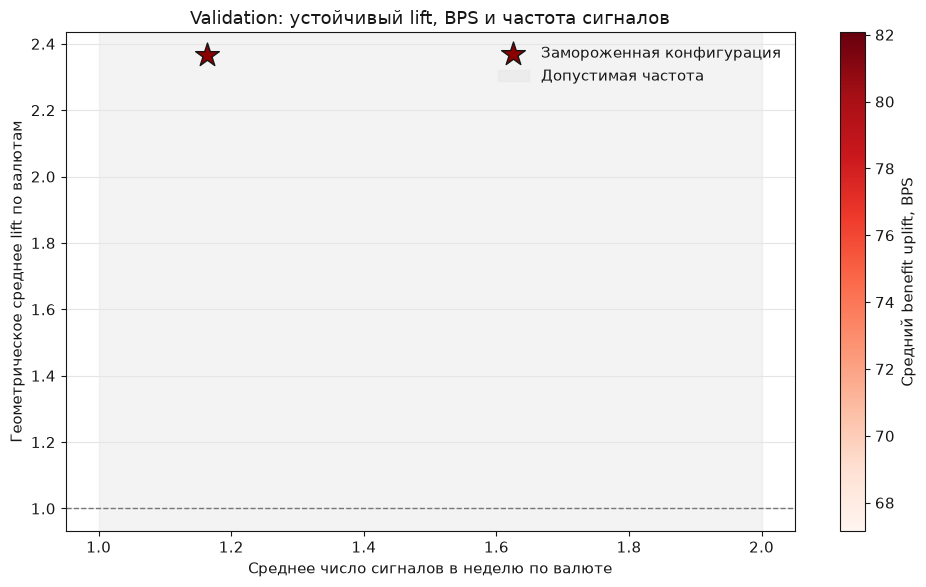

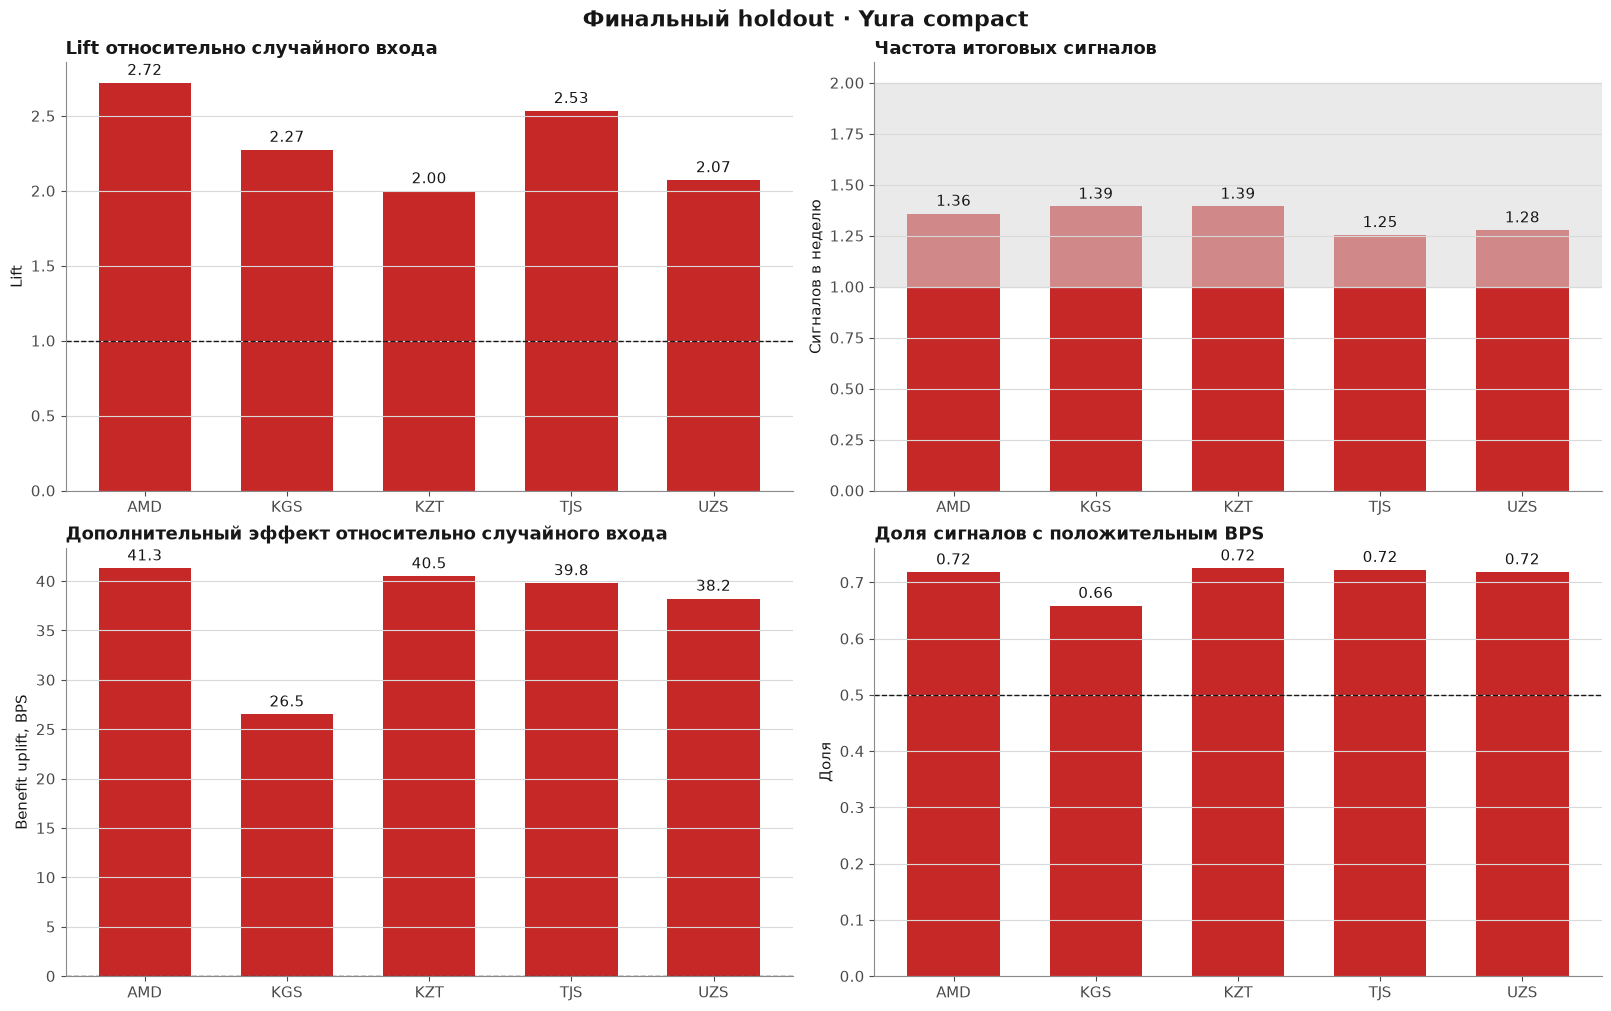

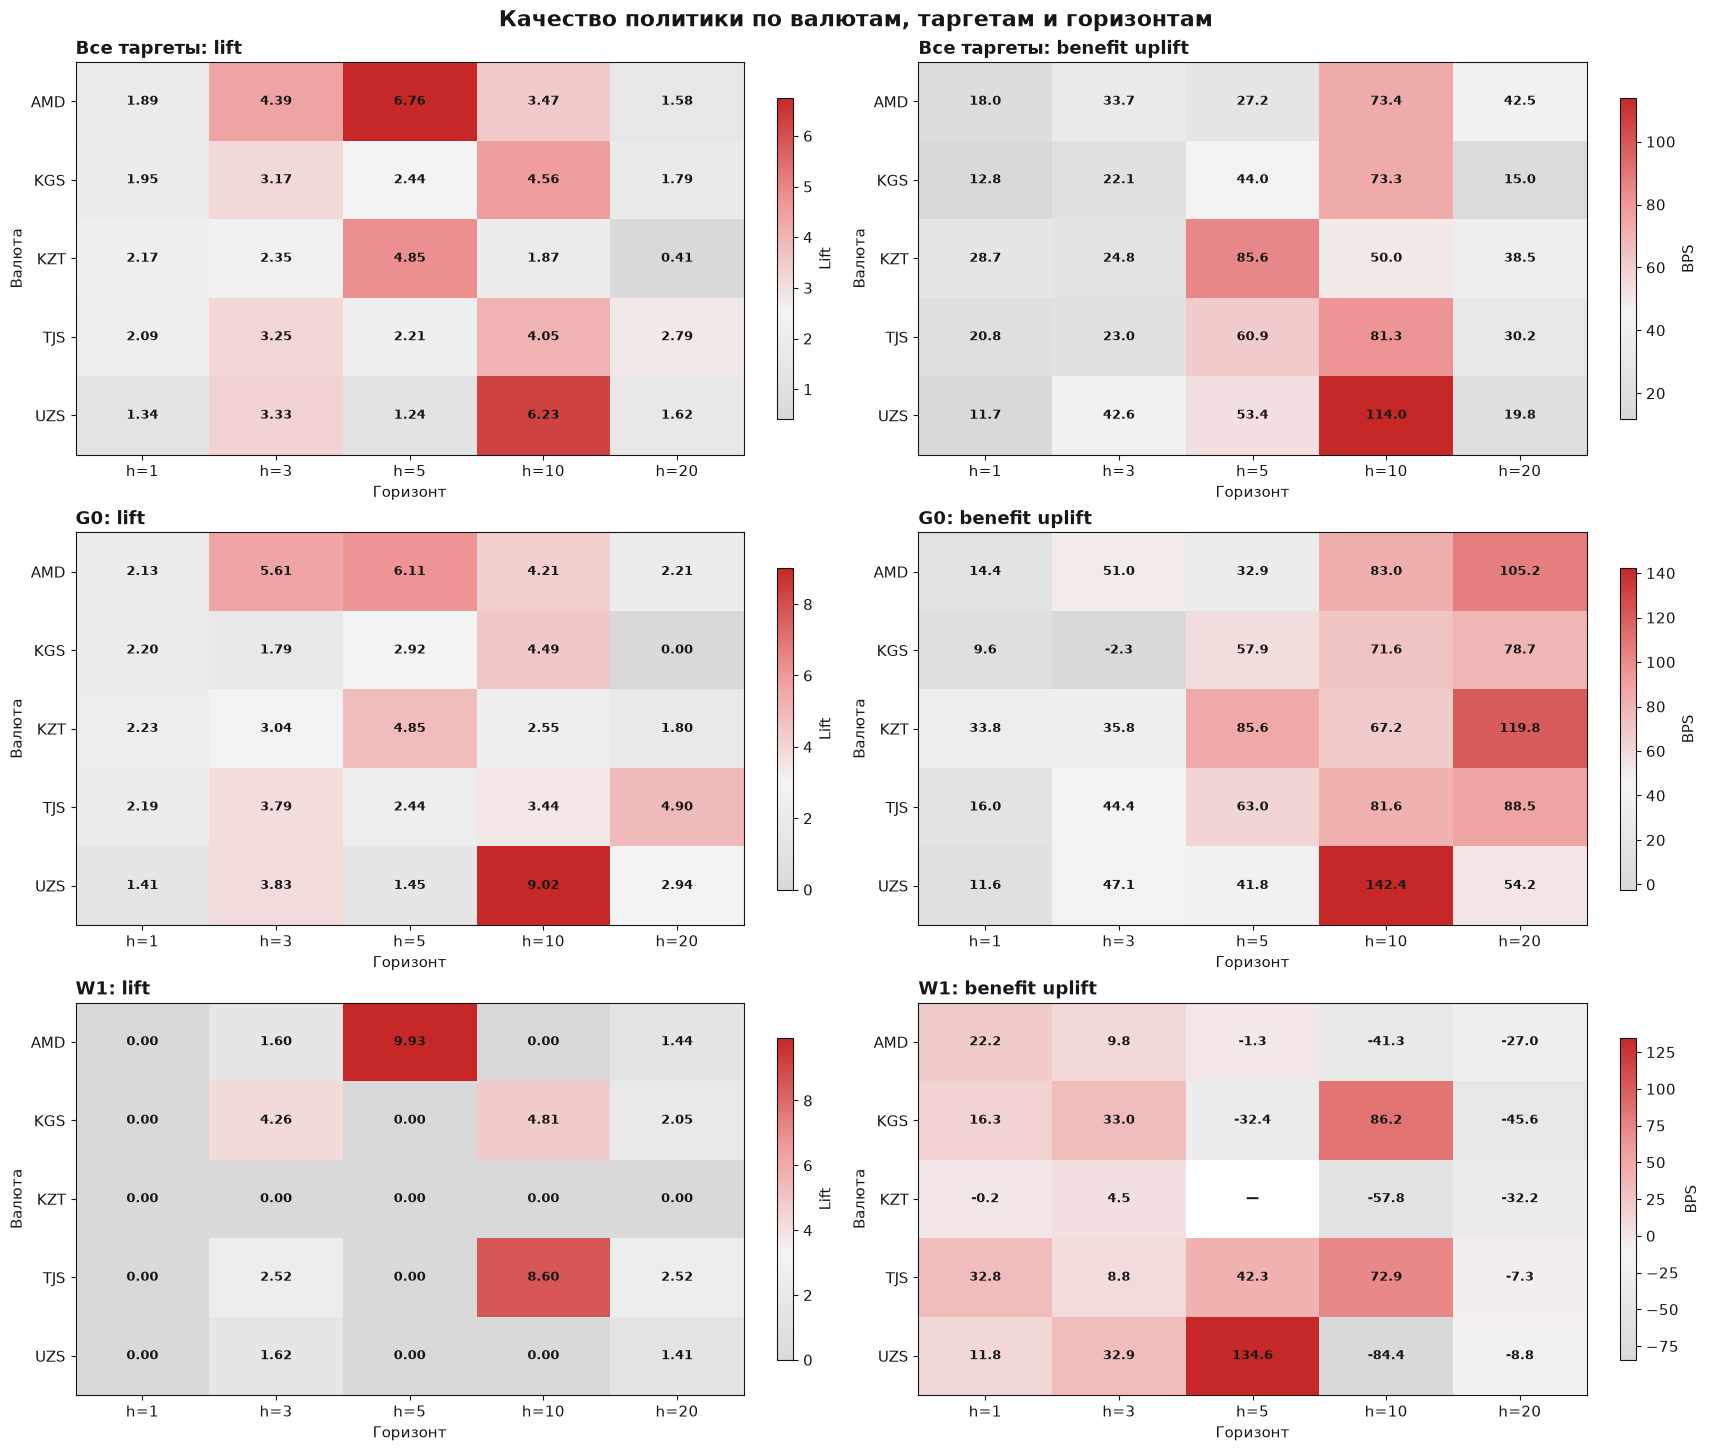

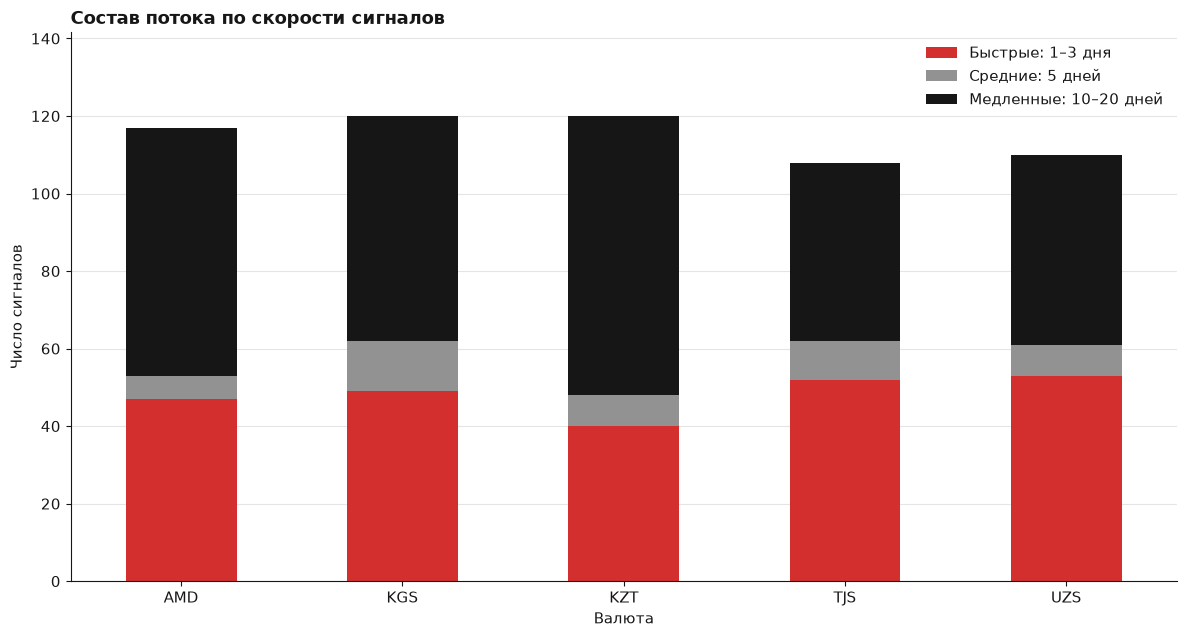

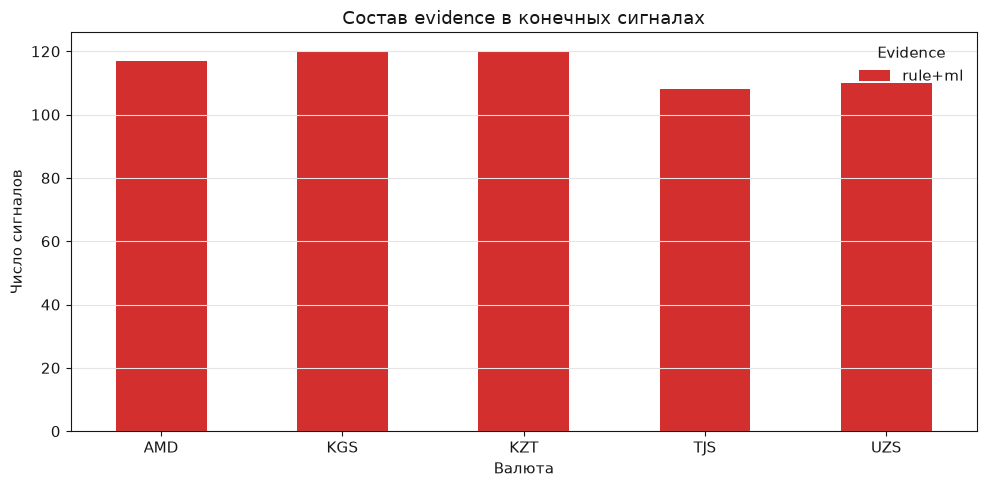

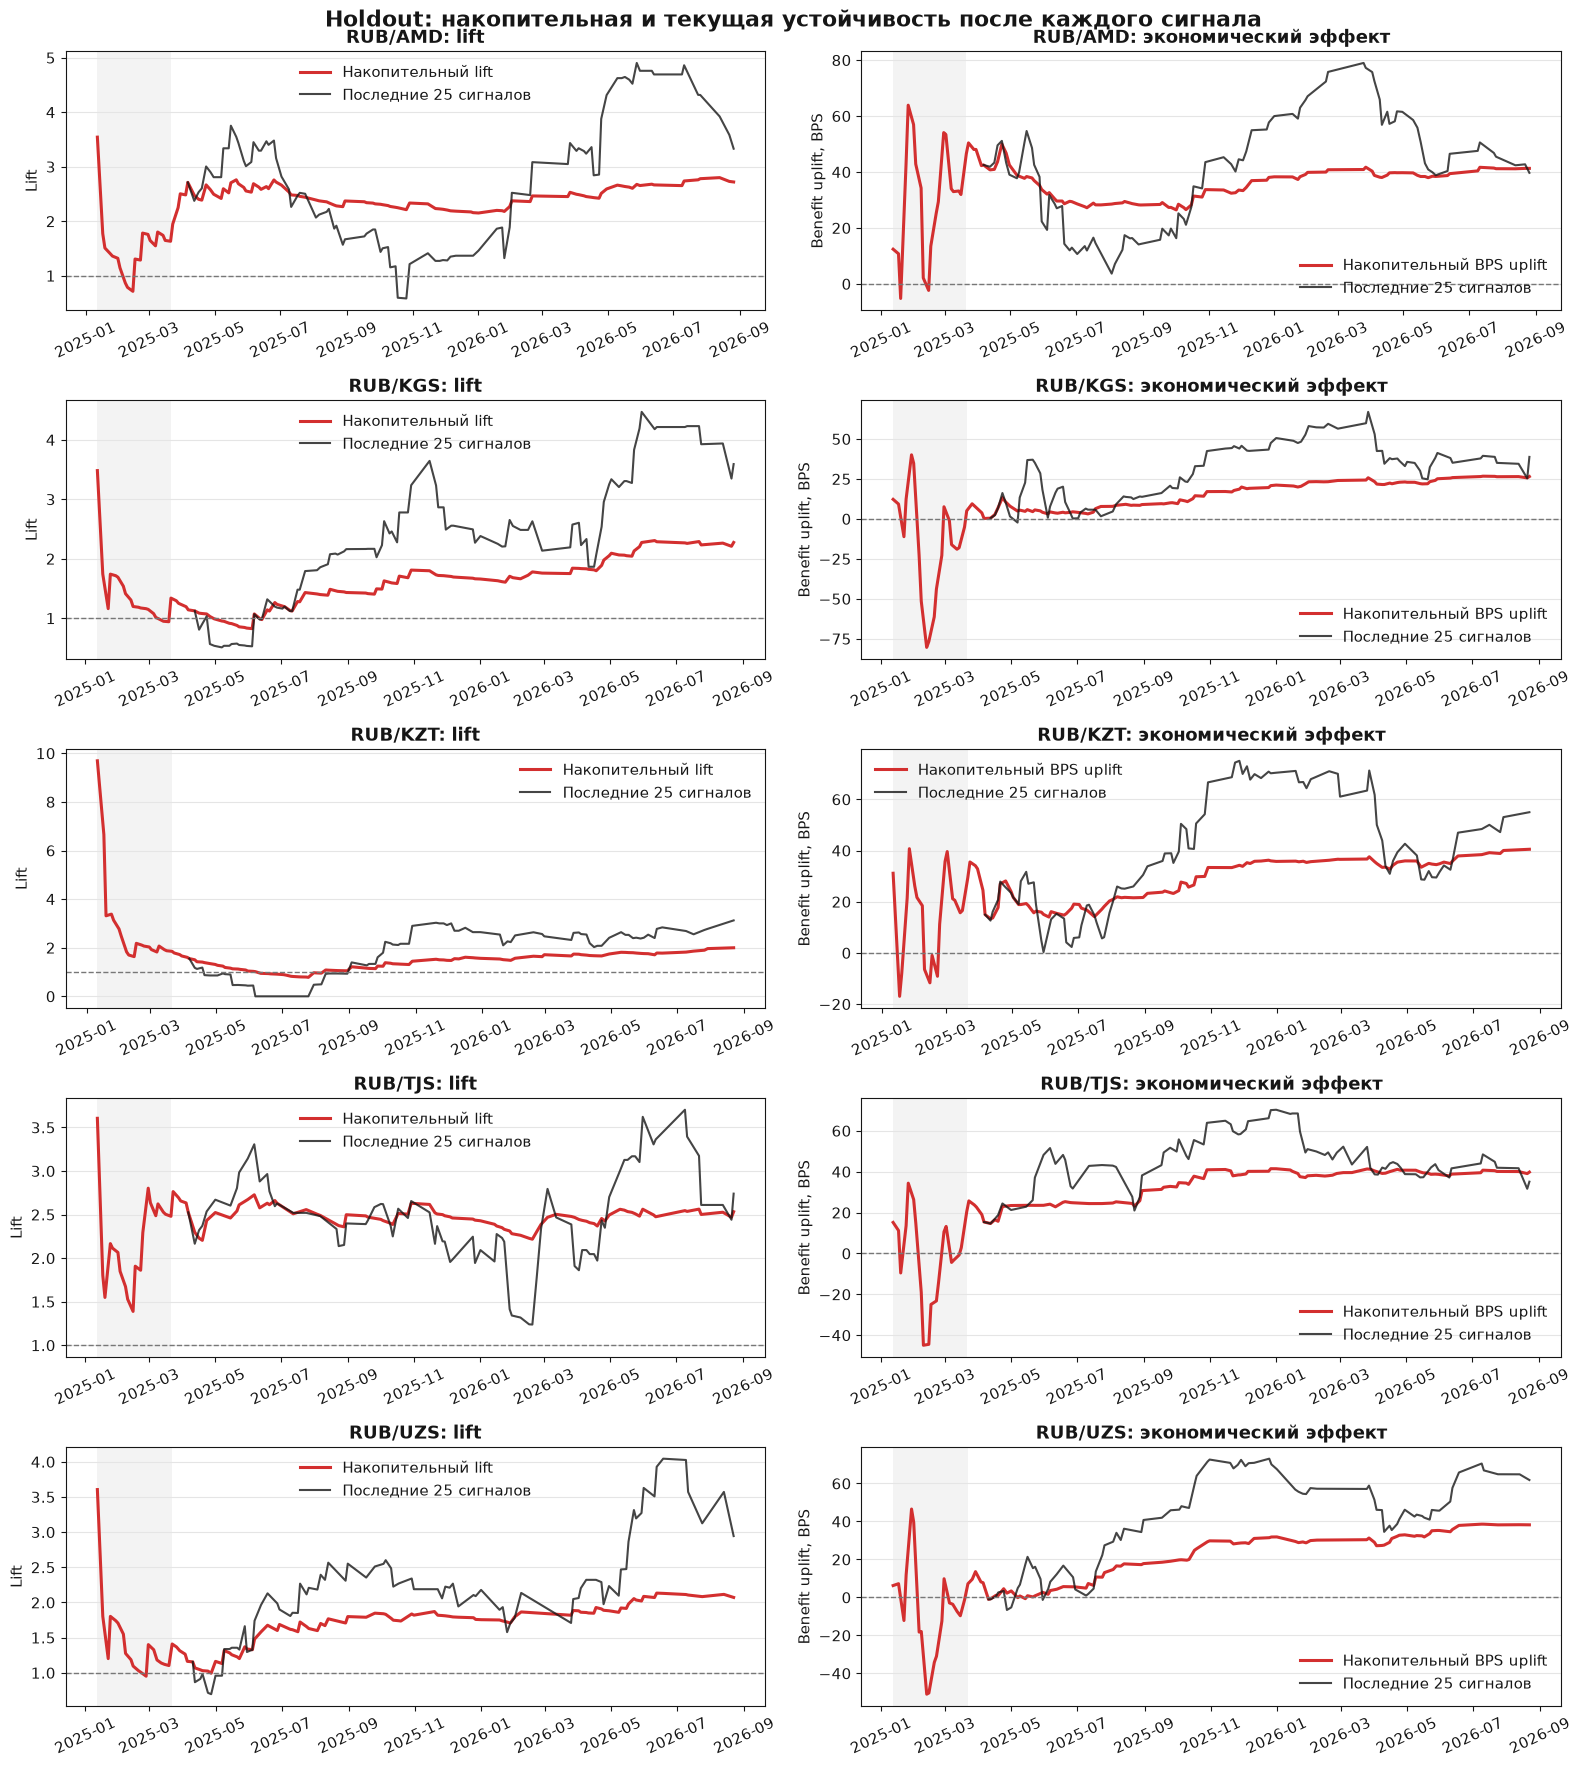

In [9]:
from importlib import reload
import research.yura.src.visualization as yura_visualization_module
reload(yura_visualization_module)

plot_validation_frontier(result.arbiter_leaderboard)
plt.show()

plot_policy_currency_overview(signal_backtest_summary, policy_name='Yura compact')
plt.show()

plot_policy_horizon_heatmaps(
    signal_backtest_summary, target_families=CONFIG.target_families,
)
plt.show()

yura_visualization_module.plot_holdout_horizon_mix(final_signal_stream)
plt.show()

plot_source_contribution(final_signal_stream)
plt.show()

plot_holdout_sequential_metrics(
    signal_backtest_rows, rolling_signals=25, warmup_signals=20,
)
plt.show()

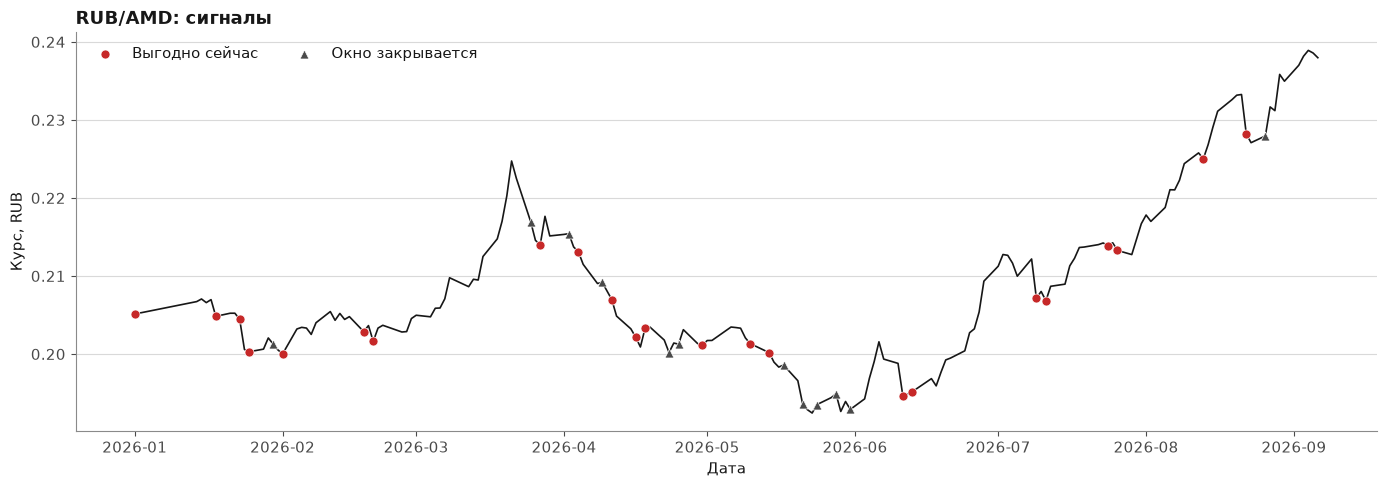

In [10]:
# Используются уже рассчитанные scoring_data и final_signal_stream.
from importlib import reload
import matplotlib.pyplot as plt
import src.visualization as signal_visualization_module
reload(signal_visualization_module)

PRESENTATION_CURRENCY = 'AMD'
fig, ax = plt.subplots(figsize=(14, 5))
signal_visualization_module.plot_signal_series(
    scoring_data,
    final_signal_stream,
    currency=PRESENTATION_CURRENCY,
    start_date='2026-01-01',  # result.temporal_plan.holdout_start,
    title=f'RUB/{PRESENTATION_CURRENCY}: сигналы',
    ax=ax,
)
fig.tight_layout()
plt.show()


### 8.1. Квартальная устойчивость lift

График использует уже рассчитанный holdout-отчёт, поэтому для его построения не требуется повторный запуск пайплайна. Подпись `n` показывает число финальных сигналов в квартале и помогает отличить отсутствие сигналов от неудачных сигналов.

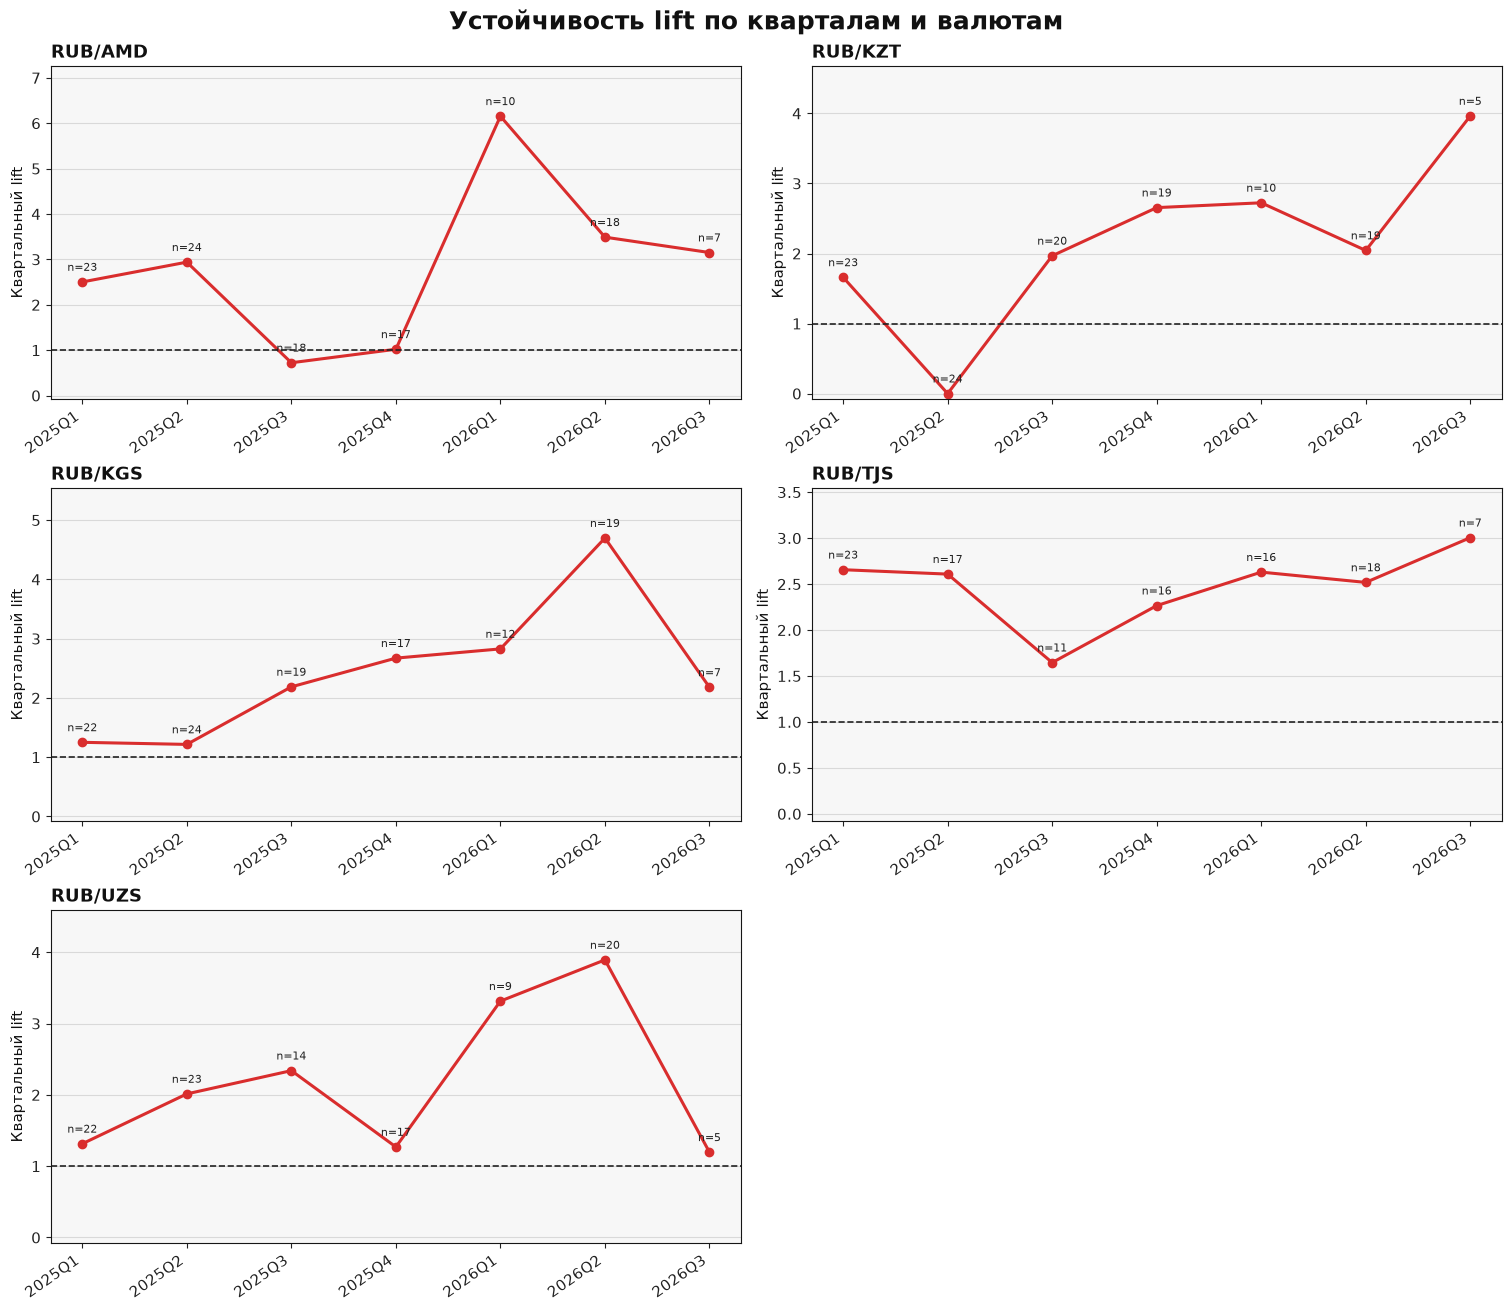

In [11]:
quarterly_lift = result.holdout_quarterly_stability.copy()
if quarterly_lift.empty:
    raise ValueError('Квартальный holdout-отчёт пуст')

quarterly_lift['quarter'] = quarterly_lift['quarter'].astype(str)
quarterly_lift['lift'] = pd.to_numeric(quarterly_lift['lift'], errors='coerce')
quarterly_lift = quarterly_lift.sort_values(['currency', 'quarter'])

currencies = [currency for currency in CONFIG.currencies if currency in set(quarterly_lift['currency'])]
fig, axes = plt.subplots(3, 2, figsize=(15, 13), constrained_layout=True)
axes = axes.ravel()

for ax, currency in zip(axes, currencies):
    currency_rows = quarterly_lift.loc[quarterly_lift['currency'].eq(currency)].reset_index(drop=True)
    positions = list(range(len(currency_rows)))

    ax.plot(
        positions, currency_rows['lift'],
        color='#D92D2D', marker='o', markersize=6, linewidth=2.2,
    )
    ax.axhline(1.0, color='#222222', linestyle='--', linewidth=1.2)
    ax.set_xticks(positions, currency_rows['quarter'], rotation=35, ha='right')
    ax.set_title(f'RUB/{currency}', loc='left', fontweight='bold', color='#111111')
    ax.set_ylabel('Квартальный lift', color='#111111')
    ax.set_facecolor('#F7F7F7')
    ax.grid(axis='y', color='#D0D0D0', linewidth=0.8, alpha=0.75)
    ax.tick_params(colors='#222222')

    finite_lift = currency_rows['lift'].dropna()
    upper_limit = max(1.25, float(finite_lift.max()) * 1.18 if not finite_lift.empty else 1.25)
    ax.set_ylim(-0.08, upper_limit)

    for position, row in currency_rows.iterrows():
        if pd.notna(row['lift']):
            ax.annotate(
                f"n={int(row['signal_count'])}",
                (position, row['lift']), xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8, color='#222222',
            )

for ax in axes[len(currencies):]:
    ax.remove()

fig.suptitle('Устойчивость lift по кварталам и валютам', fontsize=18, fontweight='bold', color='#111111')
plt.show()


### 8.2. MOEX: production-проверка актуальности и часовая история

Для проверки используются **две MOEX-котировки одной и той же бумаги**: первая фиксируется в JSON сигнала при его выпуске, вторая загружается в момент проверки. Курс ЦБ из исследовательского ряда нельзя напрямую использовать как первую цену: у него иной источник, момент фиксации и возможный базис к исполнимой цене MOEX.

Production-контракт целиком сосредоточен в `evaluate_signal_relevance(last_sent_signal, current_moex_quote)`. Для текущей клиентской операции `RUB → валюта` берётся лучший `OFFER` (ask). `LAST`, `MARKETPRICE` и `WAPRICE` возвращаются только как диагностические значения и не считаются исполнимыми. Сигнал актуален, если: (1) не закончился его горизонт; (2) есть свежий исполнимый ask; (3) бумага совпадает с зафиксированной; (4) `remaining_expected_bps = expected_bps − adverse_market_move_bps > 0`. Исходный `confidence` не меняется.

Для будущей симуляции `load_historical_moex_hourly(start='2025-01-01')` загружает часовые CETS-свечи. Их `close` становится доступен только в конце часа и явно помечен как `HOURLY_CLOSE_PROXY`: ISS-свечи не содержат исторический стакан, поэтому в replay потребуется осознанно указать `require_executable=False`.

In [12]:
from research.yura.src.moex_live import (
    evaluate_signal_relevance, load_current_moex_quotes,
    load_historical_moex_hourly,
    stamp_signals_with_moex_reference,
)

# aiomoex асинхронный; Jupyter поддерживает top-level await.
moex_quotes_at_issue = await load_current_moex_quotes(CONFIG.currencies)
display(moex_quotes_at_issue[[
    'currency', 'secid', 'board', 'bid', 'offer', 'last',
    'buy_price_source', 'buy_price_is_executable',
    'quote_at', 'fetched_at', 'trading_status',
]])

,currency,secid,board,bid,offer,last,buy_price_source,buy_price_is_executable,quote_at,fetched_at,trading_status
0,AMD,AMDRUB_TOM,CETS,NaN,NaN,23.76,LAST,False,2026-09-06 19:00:00+03:00,2026-09-06 17:33:38.952142+03:00,N
1,KGS,KGSRUB_TOM,CETS,NaN,NaN,115.00,LAST,False,2026-09-06 19:00:00+03:00,2026-09-06 17:33:38.952142+03:00,N
2,KZT,KZTRUB_TOM,CETS,NaN,NaN,19.20,LAST,False,2026-09-06 19:00:00+03:00,2026-09-06 17:33:38.952142+03:00,N
3,TJS,TJSRUB_TOM,CETS,NaN,NaN,NaN,UNAVAILABLE,False,2026-09-06 19:00:00+03:00,2026-09-06 17:33:38.952142+03:00,N
4,UZS,UZSRUB_TOM,CETS,NaN,NaN,56.00,LAST,False,2026-09-06 19:00:00+03:00,2026-09-06 17:33:38.952142+03:00,N


In [13]:
# Выполнить ОДИН РАЗ непосредственно при выпуске сегодняшних сигналов.
# Исторические holdout-сигналы намеренно не прошиваются сегодняшней ценой.
moscow_today = pd.Timestamp.now(tz='Europe/Moscow').tz_localize(None).normalize()
signal_dates = pd.to_datetime(final_signal_stream['available_at']).dt.normalize()
signals_generated_now = final_signal_stream.loc[signal_dates.eq(moscow_today)].copy()

if signals_generated_now.empty:
    print('Сегодня pipeline не сформировал финальных сигналов; MOEX snapshot загружен.')
    signals_with_market_reference = signals_generated_now.copy()
else:
    signals_with_market_reference = stamp_signals_with_moex_reference(
        signals_generated_now, moex_quotes_at_issue,
        side='BUY_FOREIGN', require_executable=True,
    )
    display(signals_with_market_reference[[
        'event_id', 'currency', 'target_family', 'horizon',
        'confidence', 'expected_bps', 'market_reference_secid',
        'market_reference_price', 'market_reference_quote_at', 'expires_at',
    ]])

Сегодня pipeline не сформировал финальных сигналов; MOEX snapshot загружен.


In [14]:
# Production: последний отправленный сигнал + текущая цена -> одно решение.
moex_quotes_now = await load_current_moex_quotes(CONFIG.currencies)
if signals_with_market_reference.empty:
    relevance_decision = None
    print('Нет сегодняшних сигналов для проверки актуальности.')
else:
    last_sent_signal = signals_with_market_reference.sort_values('issued_at').iloc[-1]
    current_quote = moex_quotes_now.loc[
        moex_quotes_now['currency'].eq(last_sent_signal['currency'])
    ].iloc[0]
    relevance_decision = evaluate_signal_relevance(
        last_sent_signal, current_quote,
    )
    display(pd.Series(relevance_decision, name='signal_relevance').to_frame())

# Отдельный загрузчик данных для будущего replay (запускать один раз при подготовке данных):
# moex_hourly = await load_historical_moex_hourly(start='2025-01-01')

Нет сегодняшних сигналов для проверки актуальности.


### 8.3. Сценарная симуляция доставки по часовым зонам России

Один и тот же замороженный поток сигналов независимо проигрывается для четырёх альтернативных часов выпуска: `09:00`, `12:00`, `15:00` и `18:00` МСК. Это взаимоисключающие продуктовые сценарии, а не четыре отправки одному клиенту. Во всех сценариях используется одно и то же случайное распределение переводов (`RANDOM_STATE`), поэтому разница результатов вызвана временем доставки и проверками актуальности.

Клиенты сначала распределяются между валютными коридорами. В каждом коридоре клиент может совершить не более двух переводов в месяц: один перевод случайно назначается на один из доступных сигналов за 1–14-е числа и один — за 15-е число–конец месяца. Если в половине месяца сигналов нет, перевода по сигналу нет. `participation_rate` задаёт долю клиентов, совершающих такой перевод в каждой половине месяца.

Сигнал исходно сформирован на состоянии рынка в `09:00` МСК. Для сценария `09:00` это уже одобренный pipeline сигнал. Для `12:00`, `15:00` и `18:00` провайдер сначала проверяет его актуальность по цене MOEX на момент предполагаемой отправки и не отправляет потерявший актуальность сигнал. Затем действует локальное окно сна `[21:00, 09:00)`: немедленно доставленный сигнал исполняется после проверки провайдера, а отложенный до 09:00 локального времени повторно проверяется клиентом по новой цене MOEX.

`rejected_by_provider` показывает отсев до отправки, `rejected_after_delivery` — отсев после отложенной доставки. `mean_realized_benefit_pct` условна на исполненных переводах, а `mean_client_savings_pct` делит суммарную экономию на объём всех назначенных потенциальных переводов; отклонённые возможности входят в её знаменатель с нулевой экономией.


In [15]:
from research.yura.src.client_simulation import (
    ClientSimulationConfig, simulate_client_timezones,
)

MOEX_HISTORY_START = pd.Timestamp('2025-01-01')
MOEX_HISTORY_END = pd.to_datetime(final_signal_stream['available_at']).max() + pd.Timedelta(days=2)
moex_hourly = await load_historical_moex_hourly(
    CONFIG.currencies, start=MOEX_HISTORY_START, end=MOEX_HISTORY_END,
)
display(moex_hourly.groupby('currency').agg(
    first_price=('available_at', 'min'),
    last_price=('available_at', 'max'),
    hourly_candles=('close', 'size'),
))

,first_price,last_price,hourly_candles
currency,,,
AMD,2025-01-03 11:00:00+03:00,2026-08-28 19:00:00+03:00,3703
KGS,2025-01-03 11:00:00+03:00,2026-08-28 16:00:00+03:00,1259
KZT,2025-01-03 10:00:00+03:00,2026-08-28 19:00:00+03:00,3646
UZS,2025-01-09 13:00:00+03:00,2026-08-24 16:00:00+03:00,344


In [16]:
# Используются уже рассчитанные final_signal_stream, signal_backtest_rows и moex_hourly.
# Основной pipeline и загрузку MOEX повторно запускать не нужно.
from importlib import reload
import research.yura.src.client_simulation as client_simulation_module
reload(client_simulation_module)

ClientSimulationConfig = client_simulation_module.ClientSimulationConfig
SIGNAL_HOURS_MSK = (9, 12, 15, 18)
TIMEZONE_SHARES = {
    "MSK": 0.7611,
    "SAMT": 0.0280,
    "YEKT": 0.0872,
    "OMST": 0.0033,
    "KRAT": 0.0423,
    "IRKT": 0.0179,
    "YAKT": 0.0238,
    "VLAT": 0.0237,
    "MAGT": 0.0079,
    "PETT": 0.0048,
}
CURRENCY_SHARES = None  # None = равные доли клиентов по валютным коридорам
RANDOM_STATE = 42

CLIENT_SIMULATION_CONFIG = ClientSimulationConfig(
    total_clients=10_000,
    average_transfer_rub=22_000.0,
    participation_rate=1.0,
    signal_hour_msk=9,  # sweep заменит его каждым сценарием
    signal_reference_hour_msk=9,
    quiet_start_hour=21,
    quiet_end_hour=9,
    max_market_price_age='2h',
    timezone_shares=TIMEZONE_SHARES,
    currency_shares=CURRENCY_SHARES,
    random_state=RANDOM_STATE,
)

timezone_scenarios = client_simulation_module.simulate_client_signal_hours(
    final_signal_stream, moex_hourly,
    evaluation_rows=signal_backtest_rows,
    signal_hours_msk=SIGNAL_HOURS_MSK,
    config=CLIENT_SIMULATION_CONFIG,
)
# Совместимость: отдельный результат сценария 09:00.
timezone_simulation = timezone_scenarios.scenario_results[9]
timezone_scenario_summary = timezone_scenarios.scenario_summary
timezone_aggregate_summary = timezone_scenarios.aggregate_summary

# Час выпуска × часовая зона; валюты объединяются по фактическим переводам.
timezone_hour_summary = client_simulation_module.aggregate_client_summary(
    timezone_scenario_summary,
    group_columns=('signal_hour_msk', 'timezone'),
)
# Средний результат четырёх альтернативных сценариев по каждой зоне.
timezone_overall_summary = client_simulation_module.aggregate_client_summary(
    timezone_aggregate_summary,
    group_columns=('timezone',),
)

display(timezone_hour_summary[[
    'signal_hour_msk', 'timezone', 'signals_considered', 'signals_sent',
    'signals_delayed', 'rejected_by_provider', 'rejected_after_delivery',
    'potential_client_transactions', 'expected_client_transactions',
    'signal_acceptance_rate', 'lift', 'mean_realized_benefit_pct',
    'mean_client_savings_pct', 'net_savings_per_client_rub',
]].style.format({
    'potential_client_transactions': '{:,.0f}',
    'expected_client_transactions': '{:,.0f}',
    'signal_acceptance_rate': '{:.1%}', 'lift': '{:.2f}',
    'mean_realized_benefit_pct': '{:.3f}%',
    'mean_client_savings_pct': '{:.3f}%',
    'net_savings_per_client_rub': '{:,.0f} ₽',
}).set_caption('Результаты каждого часа выпуска по часовым зонам'))

display(timezone_overall_summary[[
    'timezone', 'signals_considered', 'signals_sent', 'signals_delayed',
    'rejected_by_provider', 'rejected_after_delivery',
    'potential_client_transactions', 'expected_client_transactions',
    'signal_acceptance_rate', 'lift', 'mean_realized_benefit_pct',
    'mean_client_savings_pct', 'net_savings_per_client_rub',
]].style.format({
    'potential_client_transactions': '{:,.0f}',
    'expected_client_transactions': '{:,.0f}',
    'signal_acceptance_rate': '{:.1%}', 'lift': '{:.2f}',
    'mean_realized_benefit_pct': '{:.3f}%',
    'mean_client_savings_pct': '{:.3f}%',
    'net_savings_per_client_rub': '{:,.0f} ₽',
}).set_caption('Итог по четырём альтернативным часам выпуска'))


,signal_hour_msk,timezone,signals_considered,signals_sent,signals_delayed,rejected_by_provider,rejected_after_delivery,potential_client_transactions,expected_client_transactions,signal_acceptance_rate,lift,mean_realized_benefit_pct,mean_client_savings_pct,net_savings_per_client_rub
0,9,IRKT,575.000000,575.000000,0.000000,0.000000,0.000000,"6,480","6,480",100.0%,2.50,0.439%,0.439%,"3,495 ₽"
1,9,KRAT,575.000000,575.000000,0.000000,0.000000,0.000000,"15,312","15,312",100.0%,2.55,0.449%,0.449%,"3,573 ₽"
2,9,MAGT,575.000000,575.000000,0.000000,0.000000,0.000000,"2,860","2,860",100.0%,2.55,0.438%,0.438%,"3,485 ₽"
3,9,MSK,575.000000,575.000000,0.000000,0.000000,0.000000,"275,518","275,518",100.0%,2.54,0.436%,0.436%,"3,473 ₽"
4,9,OMST,575.000000,575.000000,0.000000,0.000000,0.000000,"1,194","1,194",100.0%,2.59,0.424%,0.424%,"3,374 ₽"
5,9,PETT,575.000000,575.000000,0.000000,0.000000,0.000000,"1,737","1,737",100.0%,2.61,0.451%,0.451%,"3,590 ₽"
6,9,SAMT,575.000000,575.000000,0.000000,0.000000,0.000000,"10,136","10,136",100.0%,2.55,0.440%,0.440%,"3,501 ₽"
7,9,VLAT,575.000000,575.000000,0.000000,0.000000,0.000000,"8,579","8,579",100.0%,2.50,0.434%,0.434%,"3,459 ₽"
8,9,YAKT,575.000000,575.000000,0.000000,0.000000,0.000000,"8,615","8,615",100.0%,2.52,0.426%,0.426%,"3,395 ₽"
9,9,YEKT,575.000000,575.000000,0.000000,0.000000,0.000000,"31,566","31,566",100.0%,2.51,0.433%,0.433%,"3,444 ₽"


,timezone,signals_considered,signals_sent,signals_delayed,rejected_by_provider,rejected_after_delivery,potential_client_transactions,expected_client_transactions,signal_acceptance_rate,lift,mean_realized_benefit_pct,mean_client_savings_pct,net_savings_per_client_rub
0,IRKT,575.000000,249.750000,35.000000,325.250000,35.000000,"6,480","2,369",37.3%,2.43,0.817%,0.299%,"2,378 ₽"
1,KRAT,575.000000,249.750000,35.000000,325.250000,35.000000,"15,312","5,587",37.3%,2.49,0.857%,0.313%,"2,489 ₽"
2,MAGT,575.000000,249.750000,70.250000,325.250000,70.250000,"2,860",890,31.2%,2.46,0.635%,0.197%,"1,573 ₽"
3,MSK,575.000000,249.750000,0.000000,325.250000,0.000000,"275,518","115,902",43.4%,2.49,0.909%,0.382%,"3,046 ₽"
4,OMST,575.000000,249.750000,35.000000,325.250000,35.000000,"1,194",443,37.3%,2.44,0.796%,0.295%,"2,351 ₽"
5,PETT,575.000000,249.750000,106.000000,325.250000,106.000000,"1,737",434,25.0%,2.61,0.451%,0.113%,897 ₽
6,SAMT,575.000000,249.750000,0.000000,325.250000,0.000000,"10,136","4,264",43.4%,2.50,0.901%,0.379%,"3,018 ₽"
7,VLAT,575.000000,249.750000,70.250000,325.250000,70.250000,"8,579","2,655",31.2%,2.44,0.637%,0.197%,"1,569 ₽"
8,YAKT,575.000000,249.750000,70.250000,325.250000,70.250000,"8,615","2,666",31.2%,2.45,0.642%,0.199%,"1,583 ₽"
9,YEKT,575.000000,249.750000,0.000000,325.250000,0.000000,"31,566","13,226",43.4%,2.45,0.903%,0.378%,"3,012 ₽"


### 8.4. Карта средней клиентской экономии по субъектам РФ

Карта агрегирует четыре альтернативных времени выпуска. Цвет показывает `mean_client_savings_pct`: суммарную экономию клиентов зоны, делённую на объём всех потенциальных переводов по поступившим сигналам. Поэтому отклонённый из-за задержки или потерявший актуальность сигнал получает нулевую экономию, а не исчезает из среднего. Именно это позволяет увидеть естественный территориальный градиент стоимости доставки. Lift остаётся в таблицах секции 8.3.

`MAP_CURRENCY='ALL'` объединяет валюты через общий денежный числитель и знаменатель. Можно выбрать отдельную валюту. Калининградская область исключена; для Якутии используется зона административного центра YAKT. Геометрия загружается один раз из открытого [GeoJSON субъектов РФ](https://github.com/antibioticbook/russian-geo-data) и кешируется локально.


In [ ]:
# 'ALL' — все валюты; также можно указать 'AMD', 'KGS', 'KZT', 'TJS' или 'UZS'.
from importlib import reload
import research.yura.src.timezone_map as timezone_map_module
reload(timezone_map_module)

MAP_CURRENCY = 'ALL'
RUSSIA_MAP_CACHE = PROJECT_ROOT / 'data' / 'raw' / 'maps' / 'russia_subjects.geojson'

timezone_savings_map = timezone_map_module.plot_russian_timezone_savings_map(
    timezone_aggregate_summary,
    currency=MAP_CURRENCY,
    cache_path=RUSSIA_MAP_CACHE,
)
timezone_savings_map


### 8.5. BPS-ценность быстрых и длинных сигналов

Быстрые сигналы — горизонты `1` и `3` дня, длинные — `10` и `20` дней. Горизонт `5` дней в это сравнение не входит. Столбцы показывают средний реализованный `benefit_bps` финальных holdout-сигналов; подпись `n` показывает размер соответствующей выборки. Общий столбец `Все валюты` не является средним валютных средних — он рассчитан непосредственно по всем сигналам.


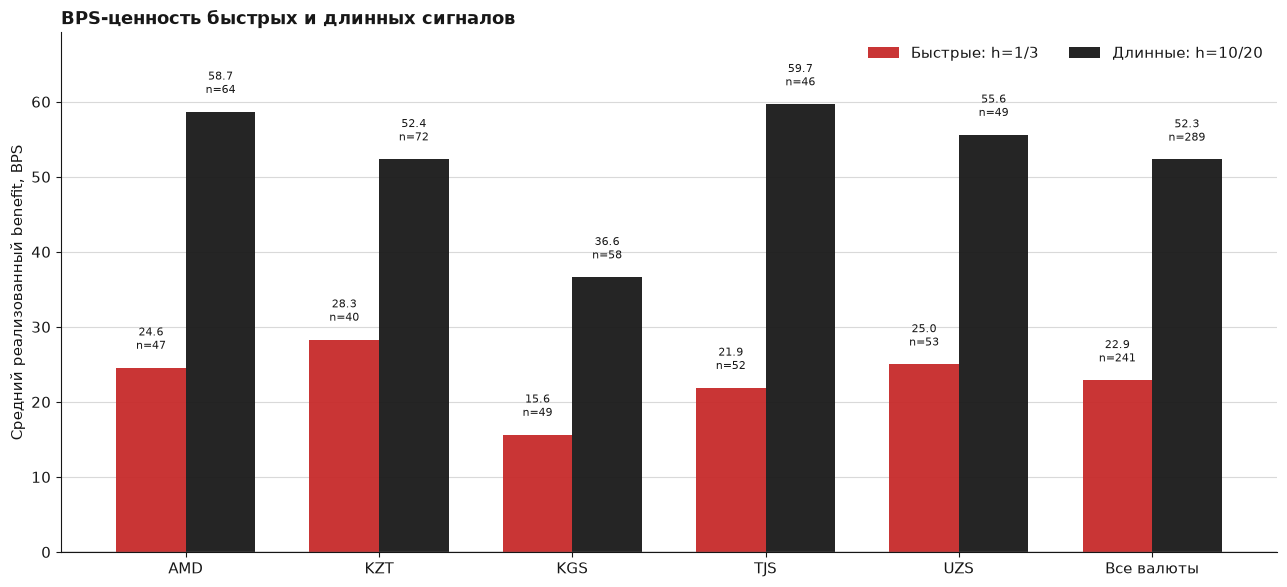

,currency,speed,signal_count,mean_benefit_bps,median_benefit_bps,positive_benefit_rate
0,AMD,Быстрые: h=1/3,47,24.6,27.3,74.5%
1,AMD,Длинные: h=10/20,64,58.7,50.9,70.3%
2,KGS,Быстрые: h=1/3,49,15.6,12.3,65.3%
3,KGS,Длинные: h=10/20,58,36.6,40.1,63.8%
4,KZT,Быстрые: h=1/3,40,28.3,14.4,75.0%
5,KZT,Длинные: h=10/20,72,52.4,46.4,68.1%
6,TJS,Быстрые: h=1/3,52,21.9,20.1,71.2%
7,TJS,Длинные: h=10/20,46,59.7,59.3,71.7%
8,UZS,Быстрые: h=1/3,53,25.0,31.5,71.7%
9,UZS,Длинные: h=10/20,49,55.6,56.9,71.4%


In [11]:
# Использует уже рассчитанный signal_backtest_rows — pipeline перезапускать не нужно.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FAST_HORIZONS = (1, 3)
SLOW_HORIZONS = (10, 20)

fast_slow_signals = signal_backtest_rows.loc[
    signal_backtest_rows['signal'].fillna(False).astype(bool)
].copy()
fast_slow_signals['horizon'] = pd.to_numeric(
    fast_slow_signals['horizon'], errors='coerce'
)
fast_slow_signals['benefit_bps'] = pd.to_numeric(
    fast_slow_signals['benefit_bps'], errors='coerce'
)
fast_slow_signals['speed'] = np.select(
    [
        fast_slow_signals['horizon'].isin(FAST_HORIZONS),
        fast_slow_signals['horizon'].isin(SLOW_HORIZONS),
    ],
    ['fast', 'slow'],
    default='excluded_h5',
)
fast_slow_signals = fast_slow_signals.loc[
    fast_slow_signals['speed'].isin(['fast', 'slow'])
].dropna(subset=['benefit_bps'])
if fast_slow_signals.empty:
    raise ValueError('В signal_backtest_rows нет финальных fast/slow-сигналов с benefit_bps')

def _summarize_fast_slow(frame, group_columns):
    return (
        frame.groupby([*group_columns, 'speed'], as_index=False)
        .agg(
            signal_count=('benefit_bps', 'size'),
            mean_benefit_bps=('benefit_bps', 'mean'),
            median_benefit_bps=('benefit_bps', 'median'),
            positive_benefit_rate=(
                'benefit_bps', lambda values: float((values > 0).mean())
            ),
        )
    )

fast_slow_bps_by_currency = _summarize_fast_slow(
    fast_slow_signals, ['currency']
)
fast_slow_bps_overall = _summarize_fast_slow(
    fast_slow_signals.assign(currency='Все валюты'), ['currency']
)
fast_slow_bps_summary = pd.concat(
    [fast_slow_bps_by_currency, fast_slow_bps_overall], ignore_index=True
)

currency_order = [
    currency for currency in CONFIG.currencies
    if currency in set(fast_slow_signals['currency'])
] + ['Все валюты']
speed_order = ['fast', 'slow']
mean_matrix = (
    fast_slow_bps_summary.pivot(
        index='currency', columns='speed', values='mean_benefit_bps'
    ).reindex(index=currency_order, columns=speed_order)
)
count_matrix = (
    fast_slow_bps_summary.pivot(
        index='currency', columns='speed', values='signal_count'
    ).reindex(index=currency_order, columns=speed_order)
)

positions = np.arange(len(currency_order))
width = 0.36
fig, ax = plt.subplots(figsize=(13, 6))
bars = []
for offset, speed, label, color in (
    (-width / 2, 'fast', 'Быстрые: h=1/3', '#C62828'),
    ( width / 2, 'slow', 'Длинные: h=10/20', '#171717'),
):
    values = mean_matrix[speed].to_numpy(dtype=float)
    current = ax.bar(
        positions + offset, values, width,
        label=label, color=color, alpha=0.94,
    )
    bars.append((current, speed, values))

ax.axhline(0, color='#777777', linewidth=1)
ax.set_xticks(positions, currency_order)
ax.set_ylabel('Средний реализованный benefit, BPS')
ax.set_title(
    'BPS-ценность быстрых и длинных сигналов',
    loc='left', fontweight='bold', color='#171717',
)
ax.grid(axis='y', color='#D9D9D9', linewidth=0.8)
ax.set_axisbelow(True)
ax.margins(y=0.16)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, ncol=2)

span = np.nanmax(np.abs(mean_matrix.to_numpy(dtype=float)))
padding = max(2.0, 0.025 * span) if np.isfinite(span) else 2.0
for current_bars, speed, values in bars:
    counts = count_matrix[speed].to_numpy(dtype=float)
    for rectangle, value, count in zip(current_bars, values, counts):
        if not np.isfinite(value):
            continue
        vertical = padding if value >= 0 else -padding
        ax.text(
            rectangle.get_x() + rectangle.get_width() / 2,
            value + vertical,
            f'{value:.1f}\nn={int(count)}',
            ha='center', va='bottom' if value >= 0 else 'top',
            fontsize=8, color='#171717',
        )

plt.tight_layout()
plt.show()

display(
    fast_slow_bps_summary.assign(
        speed=lambda frame: frame['speed'].map({
            'fast': 'Быстрые: h=1/3',
            'slow': 'Длинные: h=10/20',
        })
    )[[
        'currency', 'speed', 'signal_count', 'mean_benefit_bps',
        'median_benefit_bps', 'positive_benefit_rate',
    ]].style.format({
        'mean_benefit_bps': '{:.1f}',
        'median_benefit_bps': '{:.1f}',
        'positive_benefit_rate': '{:.1%}',
    }).set_caption('Fast/slow BPS — финальные holdout-сигналы')
)


## 9. Матрица вариантов: ML scope × selector

Один запуск сравнивает девять комбинаций: `pooled`, `hybrid`, `per_currency` × `threshold`, `logistic_regression`, `extra_trees`. Тяжёлый base walk-forward рассчитывается один раз для каждого ML scope и переиспользуется тремя selector. Holdout-столбцы служат диагностикой; выбирать победителя после просмотра holdout нельзя — выбор должен опираться на validation-столбцы.

In [12]:
from importlib import reload
import research.yura.src.pipeline as yura_pipeline_module
import research.yura.src.benchmark as yura_benchmark_module

reload(yura_pipeline_module)
reload(yura_benchmark_module)

variant_benchmark = yura_benchmark_module.run_yura_variant_matrix(
    scoring_data,
    target_registry=target_registry,
    base_config=CONFIG,
    ml_scopes=('pooled', 'hybrid', 'per_currency'),
    selector_types=('threshold', 'logistic_regression', 'extra_trees'),
)
variant_results = variant_benchmark.results
variant_comparison = variant_benchmark.summary.copy()
variant_failures = variant_benchmark.failures.copy()

comparison_columns = [
    'ml_scope', 'selector_type', 'selected_threshold', 'cooldown_days',
    'validation_geometric_lift', 'validation_min_currency_lift',
    'validation_benefit_uplift_bps', 'validation_signals_per_week',
    'holdout_signal_count', 'holdout_signals_per_week',
    'holdout_precision', 'holdout_lift', 'holdout_min_currency_lift',
    'holdout_mean_benefit_bps', 'holdout_benefit_uplift_bps',
    'holdout_positive_benefit_rate',
    'holdout_quarterly_geometric_lift', 'holdout_quarterly_lift_p10',
    'holdout_min_quarterly_lift', 'holdout_quarters_below_one',
    'holdout_nonzero_configurations',
]
display(variant_comparison.loc[:, comparison_columns].style.format({
    column: '{:.3f}'
    for column in comparison_columns
    if column not in {
        'ml_scope', 'selector_type', 'cooldown_days',
        'holdout_signal_count', 'holdout_quarters_below_one',
        'holdout_nonzero_configurations',
    }
}))

if not variant_failures.empty:
    display(variant_failures)

[pooled] base walk-forward
[pooled × threshold] selector
[pooled × logistic_regression] selector
[pooled × extra_trees] selector
[hybrid] base walk-forward
[hybrid × threshold] selector
[hybrid × logistic_regression] selector
[hybrid × extra_trees] selector
[per_currency] base walk-forward
[per_currency × threshold] selector
[per_currency × logistic_regression] selector
[per_currency × extra_trees] selector


,ml_scope,selector_type,selected_threshold,cooldown_days,validation_geometric_lift,validation_min_currency_lift,validation_benefit_uplift_bps,validation_signals_per_week,holdout_signal_count,holdout_signals_per_week,holdout_precision,holdout_lift,holdout_min_currency_lift,holdout_mean_benefit_bps,holdout_benefit_uplift_bps,holdout_positive_benefit_rate,holdout_quarterly_geometric_lift,holdout_quarterly_lift_p10,holdout_min_quarterly_lift,holdout_quarters_below_one,holdout_nonzero_configurations
0,pooled,threshold,nan,2,2.366,2.282,74.611,1.163,575,1.335,0.249,2.307,1.998,40.311,37.175,0.708,1.222,1.204,0.000,2,49
1,pooled,logistic_regression,0.050,2,2.269,2.088,25.359,1.163,528,1.226,0.468,1.926,1.578,23.009,22.414,0.723,1.968,1.362,0.999,1,28
2,pooled,extra_trees,0.100,2,2.393,2.256,27.450,1.155,535,1.242,0.436,1.904,1.669,28.972,27.560,0.738,1.926,1.281,0.883,1,25
3,hybrid,threshold,nan,2,2.414,2.232,75.103,1.156,575,1.335,0.250,2.188,1.447,49.335,45.581,0.741,2.034,1.030,0.467,4,46
4,hybrid,logistic_regression,0.050,2,2.171,1.829,22.280,1.159,529,1.228,0.459,1.898,1.641,28.696,27.875,0.747,1.926,1.271,0.752,2,28
5,hybrid,extra_trees,0.100,2,2.287,2.003,23.786,1.163,535,1.242,0.450,1.906,1.630,29.661,28.129,0.755,1.953,1.348,0.774,2,27
6,per_currency,threshold,nan,2,2.353,2.172,76.481,1.156,576,1.337,0.240,2.060,1.304,46.150,42.503,0.733,1.083,0.787,0.000,6,50
7,per_currency,logistic_regression,0.100,2,2.257,1.974,25.127,1.148,501,1.163,0.481,1.888,1.629,27.455,26.979,0.774,1.923,1.278,0.812,2,22
8,per_currency,extra_trees,0.100,2,2.266,1.966,24.534,1.155,532,1.235,0.483,1.961,1.630,27.895,26.684,0.763,2.022,1.409,1.054,0,25


### 9.1. Временная устойчивость всех вариантов

Для каждой успешно рассчитанной комбинации строятся два независимых отчёта: накопительный и rolling lift после каждого сигнала, а также несглаженный lift по календарным кварталам. Ячейка использует готовый `variant_results` и не переобучает модели.

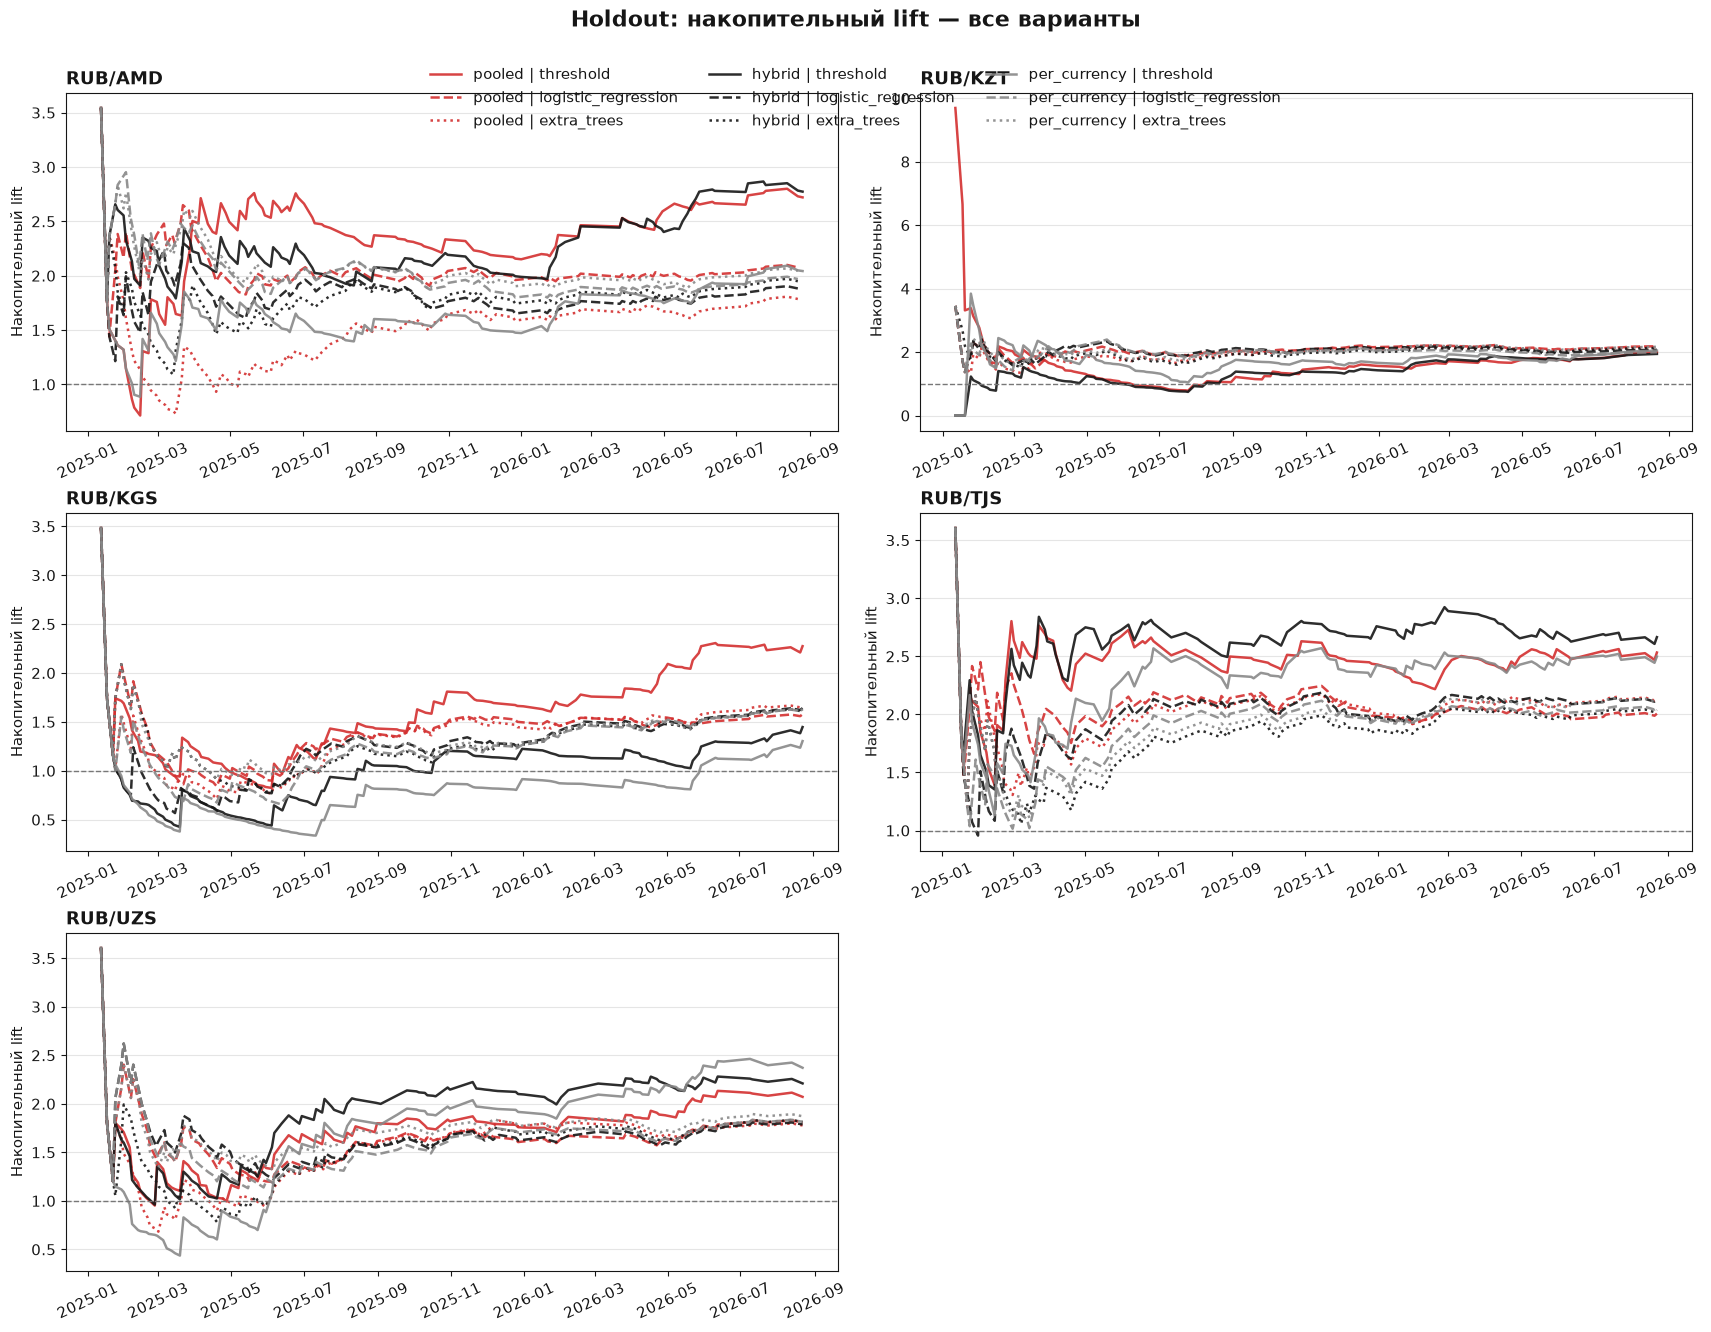

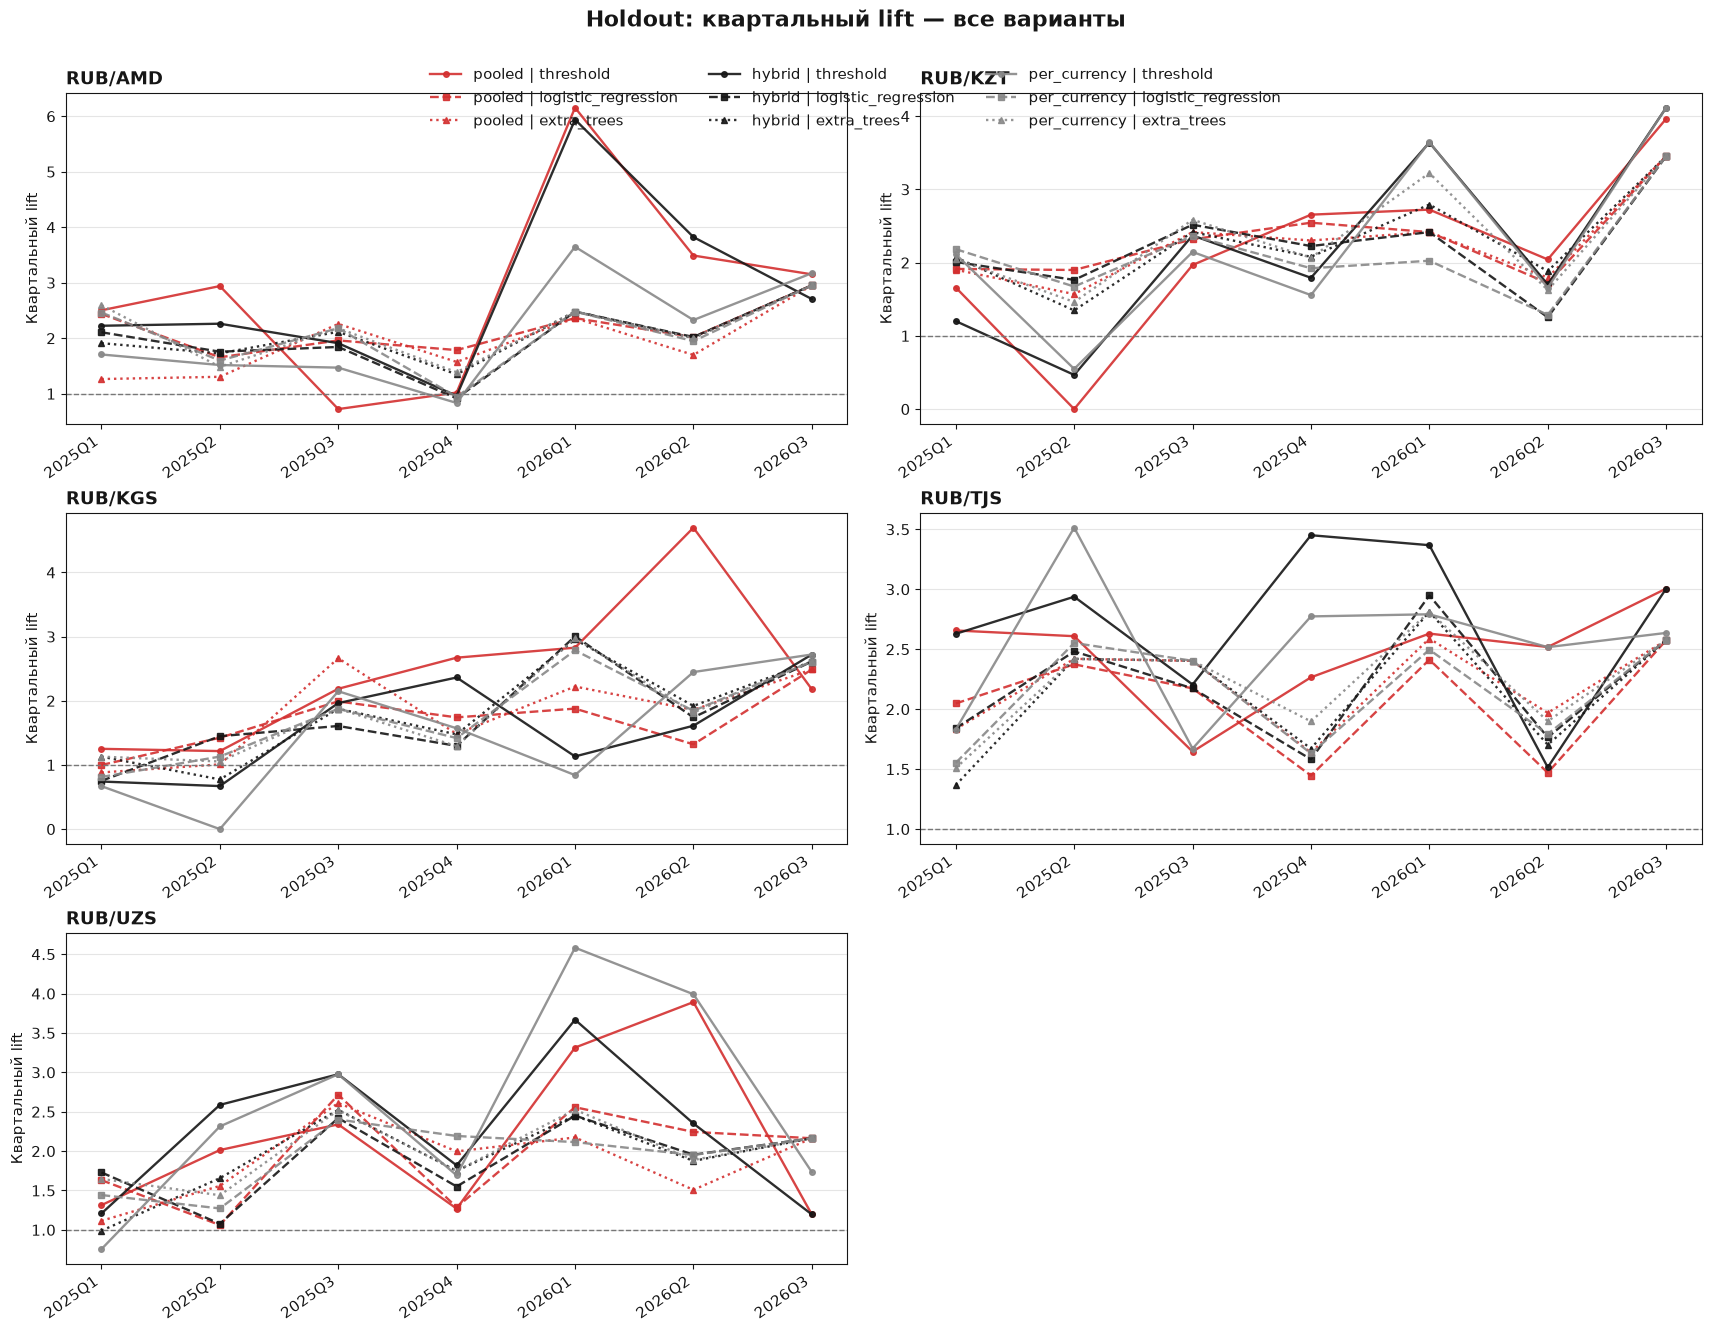

In [15]:
from IPython.display import Markdown, display
import research.yura.src.visualization as yura_visualization_module

# Две совмещённые фигуры по уже рассчитанным девяти вариантам.
reload(yura_visualization_module)

yura_visualization_module.plot_variant_cumulative_lift(variant_results)
plt.show()

yura_visualization_module.plot_variant_quarterly_lift(variant_results)
plt.show()